<a href="https://colab.research.google.com/github/Terwww/Calgary-Traffic-Analysis-by-Python/blob/main/Calgary_traffic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload Traffic_Incidents_analysis.xlsx
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving Traffic_Incidents_analysis.xlsx to Traffic_Incidents_analysis.xlsx
Uploaded: ['Traffic_Incidents_analysis.xlsx']


In [2]:
%%writefile analysis.py
#!/usr/bin/env python3
"""
Calgary Traffic Incident Analysis  (data analyst portfolio project)
====================================================================

Purpose
-------
End-to-end, reproducible analysis of City of Calgary traffic-incident open data
joined with daily weather data.  The workflow deliberately mirrors a typical
emergency-services operations analysis:

    data audit -> cleaning -> feature engineering -> EDA -> statistical testing
    -> predictive modelling -> resource re-allocation decision support -> exports

Business questions
------------------
1. Where and when do traffic incidents happen, and which quadrant / time windows
   carry the highest workload?
2. Which incidents are "prolonged" (open longer than 60 minutes), and which factors
   (location, time of day, incident type, weather) are associated with that?
3. How much does weather explain daily incident volumes once season and weekday
   are controlled for?
4. Given a fixed number of response resources, which quadrant/time-block pairs
   would benefit most from temporary support, and from which neighbouring quadrant?

Important data caveats discovered during the audit
--------------------------------------------------
* Timestamps are stored in UTC.  Calgary local time is UTC-7 / UTC-6 (daylight saving),
  so hour-of-day and calendar-day analysis must use local time.
* Records before 2022 come from a different reporting regime: MODIFIED_DT and QUADRANT
  are missing for large parts of 2019-2021 and the "EMS" wording only exists from 2021.
  Duration / severity analysis is therefore restricted to the "modern" regime.
* Several months are missing or incomplete, so month/year trend charts must exclude them.
* The EMS keyword is only present in pedestrian / cyclist incident templates.  It is
  therefore an indicator of vulnerable-road-user incidents, NOT of overall EMS demand.
* "Modified time - start time" is the time of the LAST UPDATE of the record.  It is used
  as a proxy for incident duration, not as a confirmed clearance time.
"""

from __future__ import annotations

import argparse
import logging
import sys
import traceback
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib

matplotlib.use("Agg")  # Headless backend: figures are saved to disk, never shown.
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import seaborn as sns  # noqa: E402
import statsmodels.api as sm  # noqa: E402
from scipy import stats  # noqa: E402
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor  # noqa: E402
from sklearn.inspection import permutation_importance  # noqa: E402
from sklearn.linear_model import LinearRegression, LogisticRegression  # noqa: E402
from sklearn.metrics import (  # noqa: E402
    average_precision_score,
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    precision_recall_curve,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score  # noqa: E402
from sklearn.neighbors import KNeighborsClassifier  # noqa: E402
from sklearn.pipeline import make_pipeline  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)

LOG = logging.getLogger("traffic")

# ----------------------------------------------------------------------------
# GLOBAL CONSTANTS
# ----------------------------------------------------------------------------
QUADRANTS = ["NE", "NW", "SE", "SW"]  # The four official Calgary quadrants.

# Columns we need from the incident file.  Aliases let the script also run on a raw
# Open Data Calgary export whose columns are named START_DT / MODIFIED_DT.
INCIDENT_COLUMNS = [
    "INCIDENT INFO", "DESCRIPTION", "START_DT_UTC", "MODIFIED_DT_UTC",
    "QUADRANT", "Longitude", "Latitude", "id",
]
COLUMN_ALIASES = {
    "START_DT": "START_DT_UTC",
    "MODIFIED_DT": "MODIFIED_DT_UTC",
    "INCIDENT_INFO": "INCIDENT INFO",
}
REQUIRED_INCIDENT_COLUMNS = [
    "INCIDENT INFO", "DESCRIPTION", "START_DT_UTC", "MODIFIED_DT_UTC",
    "QUADRANT", "Longitude", "Latitude",
]
WEATHER_COLUMNS = [
    "date", "min_temperature", "max_temperature", "avg_temperature",
    "avg_wind_speed", "max_wind_gust", "avg_visibility", "avg_relative_humidity",
    "precipitation", "rain", "snow", "snow_on_ground",
]

# Rush-hour definition (local hours).  Chosen from the observed evening peak at 17:00.
AM_RUSH_HOURS = (7, 8)
PM_RUSH_HOURS = (16, 17)

GAP_RATIO = 0.5          # A month is flagged as a data gap if it has < 50% of the local median.
LOAD_CAP_MIN = 240       # Cap used for durations when estimating workload (limits outlier influence).
SHRINKAGE_STRENGTH = 50  # Prior strength (pseudo-incidents) for empirical-Bayes rate shrinkage.
EXCEL_SUMMARY_CORRELATION = -0.2049  # Value found in the original Excel Summary!K2 (for reconciliation).

FINDINGS: list[str] = []  # Human-readable findings collected while the pipeline runs.


# ----------------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------------
@dataclass
class Config:
    """Container for every run-time setting so that nothing is hard-coded in the steps."""

    incidents_path: Path
    weather_path: Path
    incident_sheet: str
    weather_sheet: str
    out_dir: Path
    modern_start: str
    train_end: str
    prolonged_minutes: int
    max_valid_duration_min: int
    seed: int
    local_tz: str = "America/Edmonton"

    @property
    def fig_dir(self) -> Path:
        return self.out_dir / "figures"

    @property
    def table_dir(self) -> Path:
        return self.out_dir / "tables"

    @property
    def powerbi_dir(self) -> Path:
        return self.out_dir / "powerbi"


def parse_args(argv=None) -> Config:
    """Read command-line arguments and return a Config object."""
    parser = argparse.ArgumentParser(description="Calgary traffic incident analysis")
    parser.add_argument("--incidents", type=Path, required=True,
                        help="Incident file (.xlsx / .csv).")
    parser.add_argument("--weather", type=Path, default=None,
                        help="Weather file (.xlsx / .csv). Defaults to the incident workbook.")
    parser.add_argument("--incident-sheet", default="Traffic_Incidents_analysis")
    parser.add_argument("--weather-sheet", default="weatherstats_calgary_daily")
    parser.add_argument("--out-dir", type=Path, default=Path("outputs"))
    parser.add_argument("--modern-start", default="2022-01-01",
                        help="First date of the reliable reporting regime.")
    parser.add_argument("--train-end", default="2024-12-31",
                        help="Last date of the training period for predictive models.")
    parser.add_argument("--prolonged-minutes", type=int, default=60,
                        help="Threshold defining a prolonged incident.")
    parser.add_argument("--max-valid-duration", type=int, default=720,
                        help="Durations above this many minutes are treated as invalid.")
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args(argv)
    return Config(
        incidents_path=args.incidents,
        weather_path=args.weather or args.incidents,
        incident_sheet=args.incident_sheet,
        weather_sheet=args.weather_sheet,
        out_dir=args.out_dir,
        modern_start=args.modern_start,
        train_end=args.train_end,
        prolonged_minutes=args.prolonged_minutes,
        max_valid_duration_min=args.max_valid_duration,
        seed=args.seed,
    )


# ----------------------------------------------------------------------------
# GENERIC HELPERS
# ----------------------------------------------------------------------------
def setup_logging(out_dir: Path) -> None:
    """Log to the console and to outputs/run.log so every run is auditable."""
    out_dir.mkdir(parents=True, exist_ok=True)
    fmt = "%(asctime)s | %(levelname)-7s | %(message)s"
    logging.basicConfig(
        level=logging.INFO, format=fmt, datefmt="%H:%M:%S",
        handlers=[logging.StreamHandler(sys.stdout),
                  logging.FileHandler(out_dir / "run.log", mode="w", encoding="utf-8")],
    )


def run_step(name: str, func, *args, **kwargs):
    """Run one pipeline step; on failure log the traceback and continue with the next step.

    A long analysis should not lose every result because one late step fails.
    """
    LOG.info("=" * 78)
    LOG.info("STEP: %s", name)
    LOG.info("=" * 78)
    try:
        return func(*args, **kwargs)
    except Exception:  # noqa: BLE001 - we intentionally catch everything here
        LOG.error("Step '%s' failed:\n%s", name, traceback.format_exc())
        return None


def save_table(df: pd.DataFrame, cfg: Config, name: str, index: bool = True) -> None:
    """Write a DataFrame to outputs/tables/<name>.csv."""
    cfg.table_dir.mkdir(parents=True, exist_ok=True)
    df.to_csv(cfg.table_dir / f"{name}.csv", index=index)


def save_fig(fig: plt.Figure, cfg: Config, name: str) -> None:
    """Save a matplotlib figure to outputs/figures/<name>.png and release its memory."""
    cfg.fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(cfg.fig_dir / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)


def wilson_interval(successes, n, z: float = 1.96):
    """Wilson score confidence interval for a proportion (better than the normal
    approximation for small samples and for rates close to 0 or 1)."""
    k = np.asarray(successes, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        p = k / n
        denom = 1 + z ** 2 / n
        centre = (p + z ** 2 / (2 * n)) / denom
        half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


def holm_adjust(p_values) -> np.ndarray:
    """Holm-Bonferroni correction for multiple comparisons (controls family-wise error)."""
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running_max = 0.0
    m = len(p)
    for rank, idx in enumerate(order):
        running_max = max(running_max, (m - rank) * p[idx])
        adjusted[idx] = min(1.0, running_max)
    return adjusted


def haversine_km(lat1, lon1, lat2, lon2) -> float:
    """Great-circle distance in kilometres between two latitude/longitude points."""
    r = 6371.0088
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = phi2 - phi1
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlmb / 2) ** 2
    return float(2 * r * np.arcsin(np.sqrt(a)))


def minmax(series: pd.Series) -> pd.Series:
    """Scale a series to the 0-1 range (returns zeros if the series is constant)."""
    span = series.max() - series.min()
    return (series - series.min()) / span if span > 0 else series * 0.0


def compute_vif(x: pd.DataFrame) -> pd.Series:
    """Variance inflation factors: values above ~5-10 signal problematic multicollinearity."""
    values = x.to_numpy(dtype=float)
    vifs = {}
    for i, col in enumerate(x.columns):
        y = values[:, i]
        others = np.column_stack([np.ones(len(y)), np.delete(values, i, axis=1)])
        beta, *_ = np.linalg.lstsq(others, y, rcond=None)
        ss_res = float(((y - others @ beta) ** 2).sum())
        ss_tot = float(((y - y.mean()) ** 2).sum())
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        vifs[col] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(vifs, name="VIF")


def tidy_model(result, exponentiate: bool = False) -> pd.DataFrame:
    """Turn a fitted statsmodels result into a tidy coefficient table.

    With exponentiate=True coefficients become odds ratios (logit) or incidence-rate
    ratios (Poisson), which are far easier to explain to non-technical stakeholders.
    """
    ci = result.conf_int()
    out = pd.DataFrame({
        "coef": result.params,
        "ci_low": ci.iloc[:, 0],
        "ci_high": ci.iloc[:, 1],
        "p_value": result.pvalues,
    })
    if exponentiate:
        out[["coef", "ci_low", "ci_high"]] = np.exp(out[["coef", "ci_low", "ci_high"]])
        out = out.rename(columns={"coef": "ratio"})
    return out


def add_finding(text: str) -> None:
    """Record a finding for the final summary file and echo it to the log."""
    FINDINGS.append(text)
    LOG.info("FINDING: %s", text)


# ----------------------------------------------------------------------------
# STEP 1. LOAD DATA
# ----------------------------------------------------------------------------
def read_table(path: Path, sheet: str, wanted: list[str]) -> pd.DataFrame:
    """Read only the wanted columns from an Excel sheet or a CSV file.

    Reading a subset of columns keeps memory low (the weather sheet has 70+ columns).
    """
    wanted_set = set(wanted) | set(COLUMN_ALIASES)
    keep = lambda col: col in wanted_set  # noqa: E731
    if path.suffix.lower() in {".xlsx", ".xlsm", ".xls"}:
        return pd.read_excel(path, sheet_name=sheet, usecols=keep)
    return pd.read_csv(path, usecols=keep)


def load_data(cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load raw incident and weather tables and validate the expected columns."""
    LOG.info("Reading incidents from %s ...", cfg.incidents_path)
    incidents = read_table(cfg.incidents_path, cfg.incident_sheet, INCIDENT_COLUMNS)
    incidents = incidents.rename(columns=COLUMN_ALIASES)
    missing = [c for c in REQUIRED_INCIDENT_COLUMNS if c not in incidents.columns]
    if missing:
        raise ValueError(f"Incident file is missing required columns: {missing}")

    LOG.info("Reading weather from %s ...", cfg.weather_path)
    weather = read_table(cfg.weather_path, cfg.weather_sheet, WEATHER_COLUMNS)
    if "date" not in weather.columns:
        raise ValueError("Weather file must contain a 'date' column.")
    LOG.info("Loaded %s incident rows and %s weather rows.", f"{len(incidents):,}", f"{len(weather):,}")
    return incidents, weather


# ----------------------------------------------------------------------------
# STEP 2. RAW DATA QUALITY AUDIT
# ----------------------------------------------------------------------------
def audit_raw_incidents(raw: pd.DataFrame, cfg: Config) -> None:
    """Profile the raw file BEFORE any cleaning so that every cleaning rule is justified.

    The audit is what reveals the regime change in 2019-2021 and the EMS-keyword limitation.
    """
    start = pd.to_datetime(raw["START_DT_UTC"], errors="coerce")
    modified = pd.to_datetime(raw["MODIFIED_DT_UTC"], errors="coerce")
    duration = (modified - start).dt.total_seconds() / 60
    has_ems = raw["DESCRIPTION"].fillna("").str.contains(r"\bEMS\b", case=False, regex=True)

    summary = pd.Series({
        "raw_rows": len(raw),
        "blank_rows (no start time)": int(start.isna().sum()),
        "duplicate_ids": int(raw["id"].duplicated().sum()) if "id" in raw.columns else np.nan,
        "duplicate_records (start, lat, lon)": int(raw.duplicated(["START_DT_UTC", "Latitude", "Longitude"]).sum()),
        "missing_modified_time_pct": round(modified.isna().mean() * 100, 1),
        "missing_quadrant_pct": round(raw["QUADRANT"].isna().mean() * 100, 1),
        "first_start_utc": str(start.min()),
        "last_start_utc": str(start.max()),
        "negative_durations": int((duration < 0).sum()),
        "durations_over_24h": int((duration > 24 * 60).sum()),
    }, name="value")
    save_table(summary.to_frame(), cfg, "01_audit_summary")
    LOG.info("Audit summary:\n%s", summary.to_string())

    # Missingness by year: this exposes the reporting-regime change.
    by_year = pd.DataFrame({
        "year": start.dt.year,
        "modified_missing": modified.isna(),
        "quadrant_missing": raw["QUADRANT"].isna(),
        "ems_keyword": has_ems,
    }).dropna(subset=["year"]).groupby("year").agg(
        rows=("year", "size"),
        modified_missing_pct=("modified_missing", lambda s: round(s.mean() * 100, 1)),
        quadrant_missing_pct=("quadrant_missing", lambda s: round(s.mean() * 100, 1)),
        ems_keyword_pct=("ems_keyword", lambda s: round(s.mean() * 100, 1)),
    )
    save_table(by_year, cfg, "02_audit_by_year")
    LOG.info("Missingness and EMS keyword coverage by year:\n%s", by_year.to_string())

    bad_years = by_year[by_year["modified_missing_pct"] > 20].index.astype(int).tolist()
    if bad_years:
        add_finding(
            f"MODIFIED_DT is missing for more than 20% of records in {bad_years}; "
            f"duration analysis is restricted to records from {cfg.modern_start} onward."
        )


# ----------------------------------------------------------------------------
# STEP 3. CLEANING AND FEATURE ENGINEERING
# ----------------------------------------------------------------------------
def standardise_quadrant(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Build a reliable quadrant column using three sources, in priority order:

    1. the official QUADRANT column (upper-cased and stripped);
    2. the quadrant suffix printed at the end of INCIDENT INFO (e.g. '... SE');
    3. a spatial k-nearest-neighbour model trained on latitude/longitude (fills the rest).

    The KNN cross-validated accuracy is logged as an independent check on label quality.
    """
    raw_q = df["QUADRANT"].astype("string").str.strip().str.upper()
    raw_q = raw_q.where(raw_q.isin(QUADRANTS))

    text_q = (df["INCIDENT INFO"].astype("string").str.extract(r"\b(NE|NW|SE|SW)\s*$", expand=False,
                                                              flags=2)  # flags=2 -> re.IGNORECASE
              .str.upper())

    both = raw_q.notna() & text_q.notna()
    if both.any():
        agreement = float((raw_q[both] == text_q[both]).mean())
        LOG.info("Agreement between QUADRANT column and INCIDENT INFO suffix: %.1f%% (n=%s)",
                 agreement * 100, f"{int(both.sum()):,}")

    quadrant = raw_q.fillna(text_q)
    source = pd.Series(np.where(raw_q.notna(), "official column",
                                np.where(text_q.notna(), "text suffix", "unknown")), index=df.index)

    # Project longitude so that one unit of x and y represent similar distances in Calgary.
    lat0 = np.deg2rad(df["Latitude"].mean())
    coords = np.column_stack([df["Longitude"].to_numpy(float) * np.cos(lat0),
                              df["Latitude"].to_numpy(float)])
    known = quadrant.notna().to_numpy()
    if known.sum() > 100:
        knn = KNeighborsClassifier(n_neighbors=15, weights="distance")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.seed)
        acc = cross_val_score(knn, coords[known], quadrant[known].astype(str).to_numpy(),
                              cv=cv, scoring="accuracy").mean()
        LOG.info("Spatial KNN quadrant model, 5-fold CV accuracy: %.1f%%", acc * 100)
        unknown = ~known
        if unknown.any():
            knn.fit(coords[known], quadrant[known].astype(str).to_numpy())
            quadrant.loc[unknown] = knn.predict(coords[unknown])
            source.loc[unknown] = "spatial KNN"

    df = df.copy()
    df["quadrant"] = quadrant.astype(str)
    df["quadrant_source"] = source
    LOG.info("Quadrant source counts:\n%s", source.value_counts().to_string())
    return df


def classify_incident_type(description: pd.Series) -> pd.Series:
    """Map the free-text DESCRIPTION to a small set of incident types.

    Rules are ordered from most to least specific; the first match wins.
    """
    desc = description.fillna("").astype(str).str.lower()
    conditions = [
        desc.str.contains("pedestrian").to_numpy(),
        desc.str.contains("cyclist|bicycl").to_numpy(),
        desc.str.contains("motorcycl").to_numpy(),
        desc.str.contains(r"multi[- ]vehicle").to_numpy(),
        desc.str.contains(r"\b(?:two|2)[- ]vehicle").to_numpy(),
        desc.str.contains(r"single[- ]vehicle").to_numpy(),
        desc.str.contains("stalled").to_numpy(),
        desc.str.contains("traffic signal").to_numpy(),
        desc.str.contains("traffic incident").to_numpy(),
    ]
    choices = ["Pedestrian", "Cyclist", "Motorcycle", "Multi-vehicle", "Two-vehicle",
               "Single-vehicle", "Stalled vehicle", "Signal issue", "Generic traffic incident"]
    return pd.Series(np.select(conditions, choices, default="Other"), index=description.index)


def clean_incidents(raw: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Clean the raw incident table and engineer analysis features."""
    df = raw.copy()
    n0 = len(df)

    # 3.1 Remove blank rows (empty table rows inside the Excel table) -----------------
    df = df.dropna(subset=["START_DT_UTC", "Latitude", "Longitude"])
    LOG.info("Removed %s blank rows.", f"{n0 - len(df):,}")

    # 3.2 Remove duplicates: same id, or same time + place + description -------------
    n1 = len(df)
    if "id" in df.columns:
        df = df.drop_duplicates(subset="id", keep="first")
    df = df.drop_duplicates(subset=["START_DT_UTC", "Latitude", "Longitude", "INCIDENT INFO"], keep="first")
    LOG.info("Removed %s duplicate rows.", f"{n1 - len(df):,}")

    # 3.3 Timestamps: parse as UTC, then convert to Calgary local time -----------------
    # All hour-of-day and calendar-day logic below must use LOCAL time.
    start_utc = pd.to_datetime(df["START_DT_UTC"], errors="coerce")
    modified_utc = pd.to_datetime(df["MODIFIED_DT_UTC"], errors="coerce")
    df["start_local"] = start_utc.dt.tz_localize("UTC").dt.tz_convert(cfg.local_tz).dt.tz_localize(None)
    df["modified_local"] = modified_utc.dt.tz_localize("UTC").dt.tz_convert(cfg.local_tz).dt.tz_localize(None)
    df["date_utc"] = start_utc.dt.normalize()
    df["date_local"] = df["start_local"].dt.normalize()
    share_shifted = float((df["date_local"] != df["date_utc"]).mean())
    LOG.info("%.1f%% of incidents fall on a different calendar day in local time than in UTC.",
             share_shifted * 100)
    add_finding(f"{share_shifted:.1%} of records change calendar day when converted from UTC to Calgary "
                "local time; joining UTC dates to daily weather misaligns them.")

    # 3.4 Duration proxy (minutes between start and last update) ------------------------
    df["duration_raw_min"] = (df["modified_local"] - df["start_local"]).dt.total_seconds() / 60
    valid = df["duration_raw_min"].gt(0) & df["duration_raw_min"].le(cfg.max_valid_duration_min)
    df["duration_valid"] = valid
    df["duration_min"] = df["duration_raw_min"].where(valid)
    df["duration_cap"] = df["duration_min"].clip(upper=LOAD_CAP_MIN)
    df["log_duration"] = np.log1p(df["duration_min"])
    # Prolonged flag is NaN (not False) when the duration is unknown, so it never biases rates.
    df["prolonged"] = np.where(valid, (df["duration_raw_min"] > cfg.prolonged_minutes).astype(float), np.nan)
    LOG.info("Valid durations: %s of %s rows (%.1f%%).", f"{int(valid.sum()):,}", f"{len(df):,}",
             valid.mean() * 100)

    # 3.5 Quadrant clean-up --------------------------------------------------------------
    df = standardise_quadrant(df, cfg)

    # 3.6 Incident type and text-derived flags -----------------------------------------
    df["incident_type"] = classify_incident_type(df["DESCRIPTION"])
    desc = df["DESCRIPTION"].fillna("").astype(str).str.lower()
    df["blocking_lane"] = desc.str.contains("block").astype(float)
    df["blocking_multiple"] = desc.str.contains("multiple lanes").astype(float)
    df["ems_mentioned"] = desc.str.contains(r"\bems\b", regex=True).astype(float)
    df["vulnerable_road_user"] = df["incident_type"].isin(["Pedestrian", "Cyclist", "Motorcycle"]).astype(float)

    # 3.7 Time features (all in local time) ----------------------------------------------
    df["year"] = df["start_local"].dt.year
    df["month"] = df["start_local"].dt.month
    df["hour"] = df["start_local"].dt.hour
    df["dow"] = df["start_local"].dt.dayofweek  # Monday = 0
    df["is_weekend"] = (df["dow"] >= 5).astype(float)
    df["rush_am"] = df["hour"].isin(AM_RUSH_HOURS).astype(float)
    df["rush_pm"] = df["hour"].isin(PM_RUSH_HOURS).astype(float)
    # Cyclic encoding: 23:59 and 00:01 are close in reality, so map time onto a circle.
    minutes = df["start_local"].dt.hour * 60 + df["start_local"].dt.minute
    df["hour_sin"] = np.sin(2 * np.pi * minutes / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * minutes / 1440)
    block_start = (df["hour"] // 2) * 2
    df["time_block"] = block_start.map(lambda h: f"{h:02d}-{h + 2:02d}")
    df["season"] = df["month"].map({12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring",
                                    5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer",
                                    9: "Autumn", 10: "Autumn", 11: "Autumn"})

    # 3.8 Reporting regime flag -----------------------------------------------------------
    df["modern_regime"] = df["start_local"] >= pd.Timestamp(cfg.modern_start)

    df = df.reset_index(drop=True)
    df["row_id"] = np.arange(1, len(df) + 1)
    LOG.info("Clean table: %s rows, %s columns.", f"{len(df):,}", df.shape[1])
    return df


def build_monthly_completeness(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Flag months that are missing, partial or abnormally thin.

    A month is 'usable' when it is not the first/last (partial) month and its volume is at
    least GAP_RATIO of the rolling 13-month median.  Trend and seasonality charts use only
    usable months; the rest are shown but flagged.
    """
    counts = df.groupby(df["start_local"].dt.to_period("M")).size()
    full_index = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
    counts = counts.reindex(full_index, fill_value=0)
    reference = counts.rolling(13, center=True, min_periods=5).median()

    out = pd.DataFrame({"incidents": counts, "reference_median": reference})
    out["gap_flag"] = out["incidents"] < GAP_RATIO * out["reference_median"]
    out["edge_flag"] = False
    out.iloc[[0, -1], out.columns.get_loc("edge_flag")] = True
    out["usable"] = ~(out["gap_flag"] | out["edge_flag"])
    out.index.name = "month"
    save_table(out, cfg, "03_monthly_completeness")

    flagged = out.index[~out["usable"]].astype(str).tolist()
    LOG.info("Months excluded from trend analysis (gap or partial): %s", flagged)
    add_finding(f"{len(flagged)} of {len(out)} months are missing, partial or abnormally thin and are "
                f"excluded from trend/seasonality analysis: {', '.join(flagged)}.")
    return out


def prepare_weather(weather_raw: pd.DataFrame) -> pd.DataFrame:
    """Parse dates, coerce numerics and keep one row per calendar day."""
    wx = weather_raw.copy()
    wx["date"] = pd.to_datetime(wx["date"], errors="coerce").dt.normalize()
    for col in wx.columns.drop("date"):
        wx[col] = pd.to_numeric(wx[col], errors="coerce")
    wx = wx.dropna(subset=["date"]).drop_duplicates("date").sort_values("date")
    coverage = wx.drop(columns="date").notna().mean().mul(100).round(1)
    LOG.info("Weather variable coverage (%% of days with a value):\n%s", coverage.to_string())
    snow_days = wx["snow"].notna().sum() if "snow" in wx.columns else 0
    add_finding(f"Snow/precipitation are only recorded for {int(snow_days):,} days "
                "(recent years); temperature, wind and visibility cover the full period.")
    return wx


def build_daily_table(df: pd.DataFrame, weather: pd.DataFrame, monthly: pd.DataFrame,
                      cfg: Config) -> pd.DataFrame:
    """One row per local calendar day with incident counts and weather.

    Days with no incidents get an explicit zero, but days inside unusable months are
    flagged so they can be excluded from weather modelling.
    """
    days = pd.date_range(df["date_local"].min(), df["date_local"].max(), freq="D")
    daily = (df.groupby("date_local").size().reindex(days, fill_value=0)
             .rename("incidents").rename_axis("date").reset_index())
    daily["month_usable"] = daily["date"].dt.to_period("M").map(monthly["usable"]).fillna(False).astype(bool)
    daily["modern_regime"] = daily["date"] >= pd.Timestamp(cfg.modern_start)
    daily["dow"] = daily["date"].dt.dayofweek
    daily["month"] = daily["date"].dt.month
    daily["year"] = daily["date"].dt.year
    daily = daily.merge(weather, on="date", how="left")
    LOG.info("Daily table: %s days, %s usable.", f"{len(daily):,}", f"{int(daily['month_usable'].sum()):,}")
    return daily


def attach_weather_to_incidents(df: pd.DataFrame, weather: pd.DataFrame) -> pd.DataFrame:
    """Join daily weather (by LOCAL date) onto every incident row."""
    cols = ["date", "avg_temperature", "avg_wind_speed", "avg_visibility", "snow", "precipitation"]
    cols = [c for c in cols if c in weather.columns]
    merged = df.merge(weather[cols].rename(columns={"date": "date_local"}), on="date_local", how="left")
    return merged


# ----------------------------------------------------------------------------
# STEP 4. EXPLORATORY DATA ANALYSIS
# ----------------------------------------------------------------------------
def scope_modern(df: pd.DataFrame, monthly: pd.DataFrame) -> pd.DataFrame:
    """Rows in the modern regime that belong to usable months (safe for volume analysis)."""
    usable = df["start_local"].dt.to_period("M").map(monthly["usable"]).fillna(False).astype(bool)
    return df[df["modern_regime"] & usable]


def plot_monthly_trend(monthly: pd.DataFrame, cfg: Config) -> None:
    """Monthly incident counts, with unusable months highlighted so gaps are not mistaken for trends."""
    data = monthly.copy()
    data["ts"] = data.index.to_timestamp()
    rolling = data["incidents"].where(data["usable"]).rolling(12, min_periods=6).mean()

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(data["ts"], data["incidents"], color="#9aa5b1", lw=1.2, label="Monthly incidents")
    ax.plot(data["ts"], rolling, color="#1f5aa6", lw=2.4, label="12-month rolling mean (usable months)")
    bad = data[~data["usable"]]
    ax.scatter(bad["ts"], bad["incidents"], color="#d1495b", zorder=3, label="Gap / partial month (excluded)")
    ax.axvline(pd.Timestamp(cfg.modern_start), color="black", ls="--", lw=1)
    ax.text(pd.Timestamp(cfg.modern_start), ax.get_ylim()[1] * 0.97, "  modern reporting regime",
            va="top", fontsize=9)
    ax.set_title("Monthly traffic incidents in Calgary: gaps highlighted")
    ax.set_ylabel("Incidents per month")
    ax.legend(loc="lower left", fontsize=9)
    save_fig(fig, cfg, "01_monthly_trend")


def plot_hour_weekday_heatmap(df_scope: pd.DataFrame, daily: pd.DataFrame, cfg: Config) -> None:
    """Average incidents per hour for every weekday (normalised by the number of such days)."""
    days = daily[daily["modern_regime"] & daily["month_usable"]]
    days_per_dow = days.groupby("dow").size()
    counts = df_scope.groupby(["dow", "hour"]).size().unstack("hour").reindex(range(7)).fillna(0)
    avg = counts.div(days_per_dow, axis=0)
    avg.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    save_table(avg, cfg, "04_avg_incidents_hour_by_weekday")

    fig, ax = plt.subplots(figsize=(12, 4.5))
    sns.heatmap(avg, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Average incidents per hour"})
    ax.set_title("When do incidents happen? Average incidents by weekday and local hour")
    ax.set_xlabel("Hour of day (Calgary local time)")
    save_fig(fig, cfg, "02_hour_weekday_heatmap")

    peak = avg.stack().idxmax()
    add_finding(f"Peak incident intensity: {peak[0]} at {peak[1]:02d}:00 local "
                f"({avg.stack().max():.1f} incidents per hour on average).")


def ems_flag_coverage(df: pd.DataFrame, cfg: Config) -> None:
    """Show which incident types actually carry the EMS keyword.

    This table documents why the EMS keyword cannot be used as a measure of overall EMS demand.
    """
    modern = df[df["modern_regime"]]
    table = modern.groupby("incident_type").agg(
        incidents=("row_id", "size"),
        ems_keyword_pct=("ems_mentioned", lambda s: round(s.mean() * 100, 1)),
    ).sort_values("incidents", ascending=False)
    save_table(table, cfg, "05_ems_keyword_coverage_by_incident_type")
    LOG.info("EMS keyword coverage by incident type (modern regime):\n%s", table.to_string())
    with_ems = table[table["ems_keyword_pct"] > 0].index.tolist()
    add_finding(f"The EMS keyword appears only in these incident types: {with_ems}. It measures pedestrian/"
                "cyclist incidents, not overall EMS demand, so 'EMS rate by quadrant' must be read as a "
                "vulnerable-road-user indicator.")


def quadrant_profile(df_scope: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Compare quadrants on volume share, prolonged rate, vulnerable-road-user share and duration."""
    rows = []
    total = len(df_scope)
    for quad, g in df_scope.groupby("quadrant"):
        valid = g["prolonged"].dropna()
        rows.append({
            "quadrant": quad,
            "incidents": len(g),
            "share_of_incidents": len(g) / total,
            "prolonged_rate": valid.mean(),
            "prolonged_n": len(valid),
            "prolonged_k": valid.sum(),
            "median_duration_min": g["duration_min"].median(),
            "vru_share": g["vulnerable_road_user"].mean(),
            "vru_k": g["vulnerable_road_user"].sum(),
        })
    prof = pd.DataFrame(rows).set_index("quadrant").reindex(QUADRANTS)
    prof["prolonged_ci_low"], prof["prolonged_ci_high"] = wilson_interval(prof["prolonged_k"], prof["prolonged_n"])
    prof["vru_ci_low"], prof["vru_ci_high"] = wilson_interval(prof["vru_k"], prof["incidents"])
    save_table(prof, cfg, "06_quadrant_profile")

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].bar(prof.index, prof["share_of_incidents"] * 100, color="#4c78a8")
    axes[0].set_title("Share of incidents (%)")
    axes[1].bar(prof.index, prof["prolonged_rate"] * 100, color="#f58518",
                yerr=[(prof["prolonged_rate"] - prof["prolonged_ci_low"]) * 100,
                      (prof["prolonged_ci_high"] - prof["prolonged_rate"]) * 100], capsize=4)
    axes[1].set_title(f"Prolonged (> {cfg.prolonged_minutes} min) rate (%), 95% CI")
    axes[2].bar(prof.index, prof["vru_share"] * 100, color="#54a24b",
                yerr=[(prof["vru_share"] - prof["vru_ci_low"]) * 100,
                      (prof["vru_ci_high"] - prof["vru_share"]) * 100], capsize=4)
    axes[2].set_title("Pedestrian/cyclist/motorcycle share (%), 95% CI")
    axes[3].bar(prof.index, prof["median_duration_min"], color="#b279a2")
    axes[3].set_title("Median duration (min)")
    fig.suptitle("Quadrant profile: raw shares are NOT rates; compare risk with normalised metrics", y=1.03)
    save_fig(fig, cfg, "03_quadrant_profile")

    top = prof["prolonged_rate"].idxmax()
    add_finding(f"Highest prolonged-incident rate: {top} ({prof.loc[top, 'prolonged_rate']:.1%}, "
                f"95% CI {prof.loc[top, 'prolonged_ci_low']:.1%}-{prof.loc[top, 'prolonged_ci_high']:.1%}).")
    top_vru = prof["vru_share"].idxmax()
    add_finding(f"Highest pedestrian/cyclist/motorcycle share of incidents: {top_vru} "
                f"({prof.loc[top_vru, 'vru_share']:.1%}).")
    return prof


def plot_prolonged_heatmap(df_m: pd.DataFrame, cfg: Config) -> None:
    """Quadrant x 2-hour-block heatmap of the prolonged-incident rate (small cells masked)."""
    grid = df_m.groupby(["quadrant", "time_block"]).agg(n=("prolonged", "count"), rate=("prolonged", "mean"))
    rate = grid["rate"].where(grid["n"] >= 30).unstack("time_block").reindex(QUADRANTS)
    volume = df_m.groupby(["quadrant", "time_block"]).size().unstack("time_block").reindex(QUADRANTS)
    save_table(rate, cfg, "07_prolonged_rate_quadrant_by_block")

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    sns.heatmap(rate, annot=True, fmt=".0%", cmap="OrRd", ax=axes[0], cbar_kws={"label": "Prolonged rate"})
    axes[0].set_title(f"Share of incidents lasting > {cfg.prolonged_minutes} min (cells with n < 30 masked)")
    sns.heatmap(volume, annot=True, fmt=".0f", cmap="Blues", ax=axes[1], cbar_kws={"label": "Incidents"})
    axes[1].set_title("Incident volume in the same cells")
    for ax in axes:
        ax.set_xlabel("2-hour block (local time)")
        ax.set_ylabel("")
    save_fig(fig, cfg, "04_prolonged_rate_heatmap")


def plot_duration_distribution(df_m: pd.DataFrame, cfg: Config) -> None:
    """Show that durations are strongly right-skewed (motivates log transforms and rank tests)."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].hist(np.log10(df_m["duration_min"].dropna()), bins=60, color="#4c78a8")
    axes[0].set_xlabel("log10(duration in minutes)")
    axes[0].set_ylabel("Incidents")
    axes[0].set_title("Duration distribution (log scale)")
    sns.boxplot(data=df_m, x="quadrant", y="duration_min", order=QUADRANTS, ax=axes[1],
                color="#a0cbe8", showfliers=False)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Duration (min, log scale)")
    axes[1].set_title("Duration by quadrant")
    save_fig(fig, cfg, "05_duration_distribution")
    skew = float(stats.skew(df_m["duration_min"].dropna()))
    LOG.info("Duration skewness: %.2f (strongly right-skewed).", skew)


def hotspot_analysis(df_m: pd.DataFrame, cfg: Config) -> None:
    """Find spatial hotspots on a ~500 m grid and draw a density map."""
    grid = 0.005  # degrees; roughly 550 m north-south
    tmp = df_m.copy()
    tmp["grid_lat"] = (tmp["Latitude"] / grid).round() * grid
    tmp["grid_lon"] = (tmp["Longitude"] / grid).round() * grid
    hot = tmp.groupby(["grid_lat", "grid_lon"]).agg(
        incidents=("row_id", "size"),
        prolonged_rate=("prolonged", "mean"),
        vru_share=("vulnerable_road_user", "mean"),
        typical_location=("INCIDENT INFO", lambda s: s.mode().iat[0] if len(s.mode()) else ""),
    ).sort_values("incidents", ascending=False).head(25)
    save_table(hot, cfg, "08_top_hotspots")
    LOG.info("Top 5 hotspots:\n%s", hot.head(5).to_string())
    add_finding(f"Top hotspot cell: '{hot.iloc[0]['typical_location']}' area with {int(hot.iloc[0]['incidents']):,} "
                "incidents in the analysis window.")

    fig, ax = plt.subplots(figsize=(7, 7))
    hb = ax.hexbin(tmp["Longitude"], tmp["Latitude"], gridsize=60, bins="log", cmap="magma_r", mincnt=1)
    fig.colorbar(hb, ax=ax, label="log10(incidents)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Incident density (modern regime)")
    ax.set_aspect(1 / np.cos(np.deg2rad(tmp["Latitude"].mean())))
    save_fig(fig, cfg, "06_hotspot_density")


def incident_type_analysis(df_m: pd.DataFrame, cfg: Config) -> None:
    """Volume, median duration and prolonged rate by incident type."""
    table = df_m.groupby("incident_type").agg(
        incidents=("row_id", "size"),
        median_duration_min=("duration_min", "median"),
        prolonged_rate=("prolonged", "mean"),
    ).sort_values("incidents", ascending=False)
    table["share"] = table["incidents"] / table["incidents"].sum()
    save_table(table, cfg, "09_incident_type_summary")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    table["incidents"].sort_values().plot.barh(ax=axes[0], color="#4c78a8")
    axes[0].set_title("Incidents by type")
    (table["prolonged_rate"].sort_values() * 100).plot.barh(ax=axes[1], color="#f58518")
    axes[1].set_title("Prolonged rate by type (%)")
    save_fig(fig, cfg, "07_incident_types")


def weather_eda(daily: pd.DataFrame, cfg: Config) -> None:
    """Explore the weather / incident relationship visually and with correlations."""
    scope = daily[daily["modern_regime"] & daily["month_usable"]].dropna(subset=["avg_temperature"]).copy()
    scope["temp_bin"] = pd.cut(scope["avg_temperature"], bins=range(-35, 40, 5))
    binned = scope.groupby("temp_bin", observed=True)["incidents"].agg(["mean", "sem", "count"])
    binned = binned[binned["count"] >= 10]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].errorbar(range(len(binned)), binned["mean"], yerr=1.96 * binned["sem"], fmt="o-", color="#1f5aa6", capsize=3)
    axes[0].set_xticks(range(len(binned)))
    axes[0].set_xticklabels([f"{int(i.left)}..{int(i.right)}" for i in binned.index], rotation=45)
    axes[0].set_xlabel("Average daily temperature (deg C)")
    axes[0].set_ylabel("Incidents per day")
    axes[0].set_title("Incidents per day by temperature band (95% CI)")

    snow = scope.dropna(subset=["snow"])
    if len(snow) > 30:
        snow = snow.assign(snow_day=np.where(snow["snow"] > 0, "Snow day", "No snow"))
        sns.boxplot(data=snow, x="snow_day", y="incidents", ax=axes[1], color="#a0cbe8")
        axes[1].set_title("Incidents per day: snow vs no snow (snow data available from 2024)")
        a = snow.loc[snow["snow"] > 0, "incidents"]
        b = snow.loc[snow["snow"] == 0, "incidents"]
        if len(a) > 5 and len(b) > 5:
            u = stats.mannwhitneyu(a, b, alternative="two-sided")
            add_finding(f"On snow days Calgary averages {a.mean():.1f} incidents/day versus {b.mean():.1f} on days "
                        f"without snow (Mann-Whitney p={u.pvalue:.3g}; unadjusted for season).")
    else:
        axes[1].axis("off")
    save_fig(fig, cfg, "08_weather_eda")


def weather_correlations(daily: pd.DataFrame, cfg: Config) -> None:
    """Correlations between daily incidents and weather, raw and after removing month/weekday effects.

    Raw correlations are confounded by season (winter has both colder days and more incidents),
    so the 'partial' column controls for month-of-year and weekday.
    """
    scope = daily[daily["modern_regime"] & daily["month_usable"]].copy()
    rows = []
    for var in ["avg_temperature", "min_temperature", "max_temperature", "avg_wind_speed", "avg_visibility",
                "avg_relative_humidity", "precipitation", "snow"]:
        if var not in scope.columns:
            continue
        sub = scope[["incidents", var, "month", "dow"]].dropna()
        if len(sub) < 60:
            continue
        pearson = stats.pearsonr(sub["incidents"], sub[var])
        spearman = stats.spearmanr(sub["incidents"], sub[var])
        controls = pd.get_dummies(sub[["month", "dow"]].astype(str), drop_first=True, dtype=float)
        controls.insert(0, "const", 1.0)

        def residualise(series: pd.Series) -> np.ndarray:
            beta, *_ = np.linalg.lstsq(controls.to_numpy(), series.to_numpy(float), rcond=None)
            return series.to_numpy(float) - controls.to_numpy() @ beta

        partial = stats.pearsonr(residualise(sub["incidents"]), residualise(sub[var]))
        rows.append({"variable": var, "days": len(sub), "pearson_r": pearson.statistic,
                     "spearman_rho": spearman.statistic,
                     "partial_r_controlling_month_weekday": partial.statistic,
                     "partial_p_value": partial.pvalue})
    table = pd.DataFrame(rows).set_index("variable")
    save_table(table, cfg, "10_weather_correlations")
    LOG.info("Weather correlations:\n%s", table.round(3).to_string())
    if "avg_temperature" in table.index:
        r_raw = table.loc["avg_temperature", "pearson_r"]
        r_part = table.loc["avg_temperature", "partial_r_controlling_month_weekday"]
        rho = table.loc["avg_temperature", "spearman_rho"]
        # The wording must follow the numbers: controlling for season can weaken OR strengthen a correlation.
        if abs(r_part) < abs(r_raw):
            direction = "weaker, so season explains part of the raw association"
        else:
            direction = "stronger, so season was masking part of the relationship"
        add_finding(f"Temperature vs daily incidents: raw Pearson r={r_raw:.2f} (Spearman rho={rho:.2f}), partial r="
                    f"{r_part:.2f} after controlling for month and weekday, i.e. {direction}. Colder-than-usual days "
                    "carry more incidents, but Pearson and Spearman disagree, so a few extreme days drive the linear fit.")


def reconcile_excel_correlation(df: pd.DataFrame, weather: pd.DataFrame, cfg: Config) -> None:
    """Recompute the correlation from the original Excel Summary tab correctly.

    The Excel version (a) joined UTC dates to weather, and (b) used an un-anchored COUNTIFS
    range that silently dropped incidents.  This step shows the effect of doing it properly.
    """
    wx = weather[["date", "avg_temperature"]].dropna()
    for label, col in [("UTC dates (as in Excel, but without the range bug)", "date_utc"),
                       ("local dates (correct alignment)", "date_local")]:
        daily = df.groupby(col).size().rename("incidents")
        full = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
        daily = daily.reindex(full, fill_value=0).rename_axis("date").reset_index()
        merged = daily.merge(wx, on="date", how="inner")
        r = stats.pearsonr(merged["incidents"], merged["avg_temperature"]).statistic
        LOG.info("Correlation (%s): r=%.3f over %s days", label, r, f"{len(merged):,}")
    LOG.info("For comparison, the original Excel Summary tab reported r=%.4f.", EXCEL_SUMMARY_CORRELATION)


# ----------------------------------------------------------------------------
# STEP 5. STATISTICAL INFERENCE
# ----------------------------------------------------------------------------
def group_comparison_tests(df_m: pd.DataFrame, cfg: Config) -> None:
    """Test whether the highest-burden quadrant differs from the others, with effect sizes.

    With tens of thousands of incidents almost any difference is statistically significant,
    so effect sizes and confidence intervals matter more than p-values.
    """
    valid = df_m.dropna(subset=["duration_min"])
    rates = valid.groupby("quadrant")["prolonged"].mean()
    focus = rates.idxmax()
    a = valid.loc[valid["quadrant"] == focus, "log_duration"]
    b = valid.loc[valid["quadrant"] != focus, "log_duration"]

    # Welch t-test on log-duration (log fixes the right skew; Welch avoids equal-variance assumption).
    t = stats.ttest_ind(a, b, equal_var=False)
    pooled_sd = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    cohens_d = (a.mean() - b.mean()) / pooled_sd
    # Mann-Whitney U is rank-based and needs no distributional assumption.
    u = stats.mannwhitneyu(a, b, alternative="two-sided")
    prob_superiority = u.statistic / (len(a) * len(b))  # P(random focus incident lasts longer than other)

    # Chi-square test of independence between quadrant and prolonged status.
    contingency = pd.crosstab(valid["quadrant"], valid["prolonged"])
    chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)
    cramers_v = np.sqrt(chi2 / (contingency.to_numpy().sum() * (min(contingency.shape) - 1)))

    result = pd.Series({
        "focus_quadrant": focus, "n_focus": len(a), "n_other": len(b),
        "welch_t": t.statistic, "welch_p": t.pvalue, "cohens_d_log_duration": cohens_d,
        "mannwhitney_p": u.pvalue, "prob_superiority": prob_superiority,
        "chi2": chi2, "chi2_dof": dof, "chi2_p": p_chi, "cramers_v": cramers_v,
    })
    save_table(result.to_frame("value"), cfg, "11_group_tests_focus_vs_others")
    LOG.info("Focus-vs-others tests:\n%s", result.to_string())
    add_finding(f"{focus} vs other quadrants: Cohen's d={cohens_d:.2f} on log-duration, Cramer's V={cramers_v:.3f} "
                f"(chi-square p={p_chi:.2g}). Statistical significance is easy with this sample size; the "
                "effect sizes show whether the difference is operationally meaningful.")

    # Pairwise Mann-Whitney tests between all quadrant pairs with Holm correction.
    pairs, pvals = [], []
    for i, q1 in enumerate(QUADRANTS):
        for q2 in QUADRANTS[i + 1:]:
            x = valid.loc[valid["quadrant"] == q1, "log_duration"]
            y = valid.loc[valid["quadrant"] == q2, "log_duration"]
            pairs.append((q1, q2, x.median(), y.median()))
            pvals.append(stats.mannwhitneyu(x, y, alternative="two-sided").pvalue)
    pairwise = pd.DataFrame(pairs, columns=["quadrant_a", "quadrant_b", "median_log_a", "median_log_b"])
    pairwise["p_raw"] = pvals
    pairwise["p_holm"] = holm_adjust(pvals)
    save_table(pairwise, cfg, "12_pairwise_quadrant_tests", index=False)


def build_features(df: pd.DataFrame, quadrant_ref: str) -> pd.DataFrame:
    """Numeric design matrix shared by the regression and machine-learning steps.

    Categorical variables are one-hot encoded with an explicit reference level so that
    regression coefficients are interpretable ('versus the reference category').
    """
    x = pd.DataFrame(index=df.index)
    x["hour_sin"] = df["hour_sin"]
    x["hour_cos"] = df["hour_cos"]
    x["is_weekend"] = df["is_weekend"]
    x["rush_am"] = df["rush_am"]
    x["rush_pm"] = df["rush_pm"]
    x["blocking_lane"] = df["blocking_lane"]
    x["blocking_multiple"] = df["blocking_multiple"]
    x["temp_10c"] = df["avg_temperature"] / 10
    x["wind_10kmh"] = df["avg_wind_speed"] / 10
    x["visibility_10km"] = df["avg_visibility"] / 10
    quad = pd.get_dummies(df["quadrant"], prefix="quad", dtype=float).drop(columns=f"quad_{quadrant_ref}")
    typ = pd.get_dummies(df["incident_type"], prefix="type", dtype=float).drop(columns="type_Generic traffic incident",
                                                                              errors="ignore")
    season = pd.get_dummies(df["season"], prefix="season", dtype=float).drop(columns="season_Summer", errors="ignore")
    return pd.concat([x, quad, typ, season], axis=1).astype(float)


def logistic_regression(df_m: pd.DataFrame, cfg: Config) -> None:
    """Logistic regression of 'prolonged incident' on location, time, type and weather.

    Odds ratios show the independent association of each factor after adjusting for the rest,
    which is what a simple pivot table cannot do.
    """
    quadrant_ref = df_m["quadrant"].value_counts().idxmax()
    data = df_m.dropna(subset=["prolonged", "avg_temperature", "avg_wind_speed", "avg_visibility"])
    x = build_features(data, quadrant_ref)
    y = data["prolonged"].astype(float)

    vif = compute_vif(x)
    save_table(vif.to_frame(), cfg, "13_logit_vif")
    LOG.info("Maximum VIF: %.2f (%s)", vif.max(), vif.idxmax())

    model = sm.Logit(y, sm.add_constant(x, has_constant="add")).fit(disp=False, maxiter=200)
    table = tidy_model(model, exponentiate=True).rename(columns={"ratio": "odds_ratio"})
    save_table(table, cfg, "14_logit_odds_ratios")
    auc = roc_auc_score(y, model.predict(sm.add_constant(x, has_constant="add")))
    LOG.info("Logit: n=%s, pseudo R2=%.3f, in-sample AUC=%.3f, reference quadrant=%s",
             f"{int(model.nobs):,}", model.prsquared, auc, quadrant_ref)

    sig = table.drop(index="const")
    sig = sig[sig["p_value"] < 0.01].sort_values("odds_ratio", ascending=False)
    if len(sig):
        best = sig.iloc[0]
        add_finding(f"Strongest adjusted association with prolonged incidents: {sig.index[0]} "
                    f"(odds ratio {best['odds_ratio']:.2f}, 95% CI {best['ci_low']:.2f}-{best['ci_high']:.2f}); "
                    f"quadrant reference = {quadrant_ref}.")

    plot_data = table.drop(index="const").sort_values("odds_ratio")
    fig, ax = plt.subplots(figsize=(8, max(5, 0.28 * len(plot_data))))
    ax.errorbar(plot_data["odds_ratio"], range(len(plot_data)),
                xerr=[plot_data["odds_ratio"] - plot_data["ci_low"], plot_data["ci_high"] - plot_data["odds_ratio"]],
                fmt="o", color="#1f5aa6", capsize=2)
    ax.axvline(1, color="black", lw=1)
    ax.set_xscale("log")
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(plot_data.index, fontsize=8)
    ax.set_xlabel("Odds ratio (log scale, 95% CI)")
    ax.set_title(f"Odds of a prolonged incident (> {cfg.prolonged_minutes} min)")
    save_fig(fig, cfg, "09_logit_forest_plot")


def daily_count_models(daily: pd.DataFrame, cfg: Config) -> None:
    """Poisson regression (robust standard errors) of daily incident counts on weather.

    Model A uses variables available for the whole modern period; Model B adds snow and
    precipitation, which are only recorded from 2024.  Exponentiated coefficients are
    incidence-rate ratios (IRR): 1.10 means 10% more incidents per day per unit increase.
    """
    scope = daily[daily["modern_regime"] & daily["month_usable"]].copy()
    scope["t_years"] = (scope["date"] - scope["date"].min()).dt.days / 365.25

    def design(frame: pd.DataFrame, extra: list[str]) -> pd.DataFrame:
        x = pd.DataFrame({"t_years": frame["t_years"], "temp_10c": frame["avg_temperature"] / 10,
                          "wind_10kmh": frame["avg_wind_speed"] / 10,
                          "visibility_10km": frame["avg_visibility"] / 10}, index=frame.index)
        for col in extra:
            x[col] = frame[col]
        dow = pd.get_dummies(frame["dow"].map(dict(enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]))),
                             prefix="dow", dtype=float).drop(columns="dow_Mon")
        month = pd.get_dummies(frame["month"], prefix="month", dtype=float).drop(columns="month_1")
        return sm.add_constant(pd.concat([x, dow, month], axis=1).astype(float), has_constant="add")

    for name, extra, subset in [
        ("A_weather_no_snow", [], scope.dropna(subset=["avg_temperature", "avg_wind_speed", "avg_visibility"])),
        ("B_with_snow", ["snow_day", "precip_10mm"],
         scope.assign(snow_day=lambda d: (d["snow"] > 0).astype(float),
                      precip_10mm=lambda d: d["precipitation"] / 10)
         .dropna(subset=["avg_temperature", "avg_wind_speed", "avg_visibility", "snow", "precipitation"])),
    ]:
        if len(subset) < 100:
            LOG.warning("Model %s skipped: only %s days available.", name, len(subset))
            continue
        x = design(subset, extra)
        result = sm.GLM(subset["incidents"].astype(float), x, family=sm.families.Poisson()).fit(cov_type="HC1")
        table = tidy_model(result, exponentiate=True).rename(columns={"ratio": "IRR"})
        save_table(table, cfg, f"15_poisson_daily_model_{name}")
        dispersion = result.pearson_chi2 / result.df_resid
        LOG.info("Poisson model %s: %s days, Pearson dispersion=%.2f (>1 means over-dispersion; robust SEs used).",
                 name, f"{int(result.nobs):,}", dispersion)
        for term in ["temp_10c", "snow_day", "visibility_10km"]:
            if term in table.index:
                row = table.loc[term]
                add_finding(f"Model {name}: {term} IRR={row['IRR']:.2f} "
                            f"(95% CI {row['ci_low']:.2f}-{row['ci_high']:.2f}, p={row['p_value']:.2g}).")


def segment_models(df_m: pd.DataFrame, cfg: Config) -> None:
    """One OLS model per quadrant for log-duration, analogous to hospital-specific models.

    The rush-hour coefficient is converted to a percentage change in duration
    ((exp(beta) - 1) x 100), with heteroskedasticity-robust (HC3) confidence intervals.
    """
    rows = []
    for quad in QUADRANTS:
        sub = df_m[df_m["quadrant"] == quad].dropna(subset=["log_duration"])
        if len(sub) < 200:
            continue
        typ = pd.get_dummies(sub["incident_type"], prefix="type", dtype=float).drop(
            columns="type_Generic traffic incident", errors="ignore")
        x = pd.concat([sub[["rush_am", "rush_pm", "hour_sin", "hour_cos", "is_weekend", "blocking_lane"]], typ],
                      axis=1).astype(float)
        result = sm.OLS(sub["log_duration"].astype(float), sm.add_constant(x, has_constant="add")).fit(cov_type="HC3")
        ci = result.conf_int()
        for term in ["rush_am", "rush_pm"]:
            rows.append({
                "quadrant": quad, "term": term, "n": int(result.nobs),
                "pct_change_in_duration": (np.exp(result.params[term]) - 1) * 100,
                "ci_low_pct": (np.exp(ci.loc[term].iloc[0]) - 1) * 100,
                "ci_high_pct": (np.exp(ci.loc[term].iloc[1]) - 1) * 100,
                "p_value": result.pvalues[term], "r_squared": result.rsquared,
            })
    table = pd.DataFrame(rows)
    save_table(table, cfg, "16_quadrant_ols_rush_hour_effects", index=False)
    LOG.info("Rush-hour effect on duration by quadrant:\n%s", table.round(3).to_string(index=False))

    pivot = df_m.groupby(["quadrant", "time_block"])["duration_min"].mean().unstack("time_block").reindex(QUADRANTS)
    fig, ax = plt.subplots(figsize=(12, 3.8))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Mean duration (min)"})
    ax.set_title("Mean incident duration by quadrant and 2-hour block")
    ax.set_xlabel("2-hour block (local time)")
    ax.set_ylabel("")
    save_fig(fig, cfg, "10_mean_duration_heatmap")


# ----------------------------------------------------------------------------
# STEP 6. PREDICTIVE MODELLING
# ----------------------------------------------------------------------------
def regression_metrics(y_true_log, y_pred_log) -> dict:
    """Metrics on both the log scale (what is modelled) and the minute scale (what people read)."""
    y_true_min = np.expm1(y_true_log)
    y_pred_min = np.expm1(np.clip(y_pred_log, 0, None))
    return {
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "RMSE_log": float(np.sqrt(mean_squared_error(y_true_log, y_pred_log))),
        "R2_log": r2_score(y_true_log, y_pred_log),
        "MAE_min": mean_absolute_error(y_true_min, y_pred_min),
        "MedianAE_min": median_absolute_error(y_true_min, y_pred_min),
    }


def predict_duration(df_m: pd.DataFrame, cfg: Config) -> None:
    """Predict log-duration with a chronological train/test split.

    A time-based split mimics real deployment (train on the past, predict the future) and avoids
    the optimistic bias of a random split.  Incident durations are inherently noisy, so a modest
    R2 is expected; the value of the exercise is in the comparison with a naive baseline and in
    the drivers that the model surfaces.
    """
    quadrant_ref = df_m["quadrant"].value_counts().idxmax()
    data = df_m.dropna(subset=["log_duration", "avg_temperature", "avg_wind_speed", "avg_visibility"]).copy()
    x_all = build_features(data, quadrant_ref)
    y_all = data["log_duration"]
    is_train = (data["start_local"] <= pd.Timestamp(cfg.train_end)).to_numpy()
    x_train, x_test = x_all[is_train], x_all[~is_train]
    y_train, y_test = y_all[is_train], y_all[~is_train]
    LOG.info("Train rows: %s (<= %s); test rows: %s.", f"{len(x_train):,}", cfg.train_end, f"{len(x_test):,}")
    if len(x_test) < 200 or len(x_train) < 500:
        raise ValueError("Not enough rows for a train/test split; adjust --train-end or --modern-start.")

    results = {}
    # Baseline 0: always predict the training median (the benchmark every model must beat).
    results["Naive median baseline"] = regression_metrics(y_test, np.full(len(y_test), y_train.median()))

    # Baseline 1: linear regression with only time and quadrant information.
    time_cols = [c for c in x_all.columns if c.startswith(("hour_", "quad_", "rush_")) or c == "is_weekend"]
    lin_simple = LinearRegression().fit(x_train[time_cols], y_train)
    results["Linear (time + quadrant)"] = regression_metrics(y_test, lin_simple.predict(x_test[time_cols]))

    # Model 2: linear regression with every feature.
    lin_full = LinearRegression().fit(x_train, y_train)
    results["Linear (all features)"] = regression_metrics(y_test, lin_full.predict(x_test))

    # Model 3: random forest captures non-linearities and interactions automatically.
    forest = RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=25, n_jobs=-1,
                                   random_state=cfg.seed)
    forest.fit(x_train, y_train)
    forest_pred = forest.predict(x_test)
    results["Random forest"] = regression_metrics(y_test, forest_pred)

    metrics = pd.DataFrame(results).T
    save_table(metrics, cfg, "17_duration_model_comparison")
    LOG.info("Duration model comparison (test set):\n%s", metrics.round(3).to_string())
    # RMSE on the log scale is the primary metric because the models are fitted with squared error.
    best = metrics["RMSE_log"].idxmin()
    baseline_rmse = metrics.loc["Naive median baseline", "RMSE_log"]
    if best == "Naive median baseline":
        add_finding(f"Duration prediction (test period after {cfg.train_end[:4]}): NO model beat the naive median "
                    f"baseline (best log-scale R2 among models = {metrics.drop('Naive median baseline')['R2_log'].max():.2f}). "
                    "Incident duration cannot be predicted from time, place, incident type and weather alone; "
                    "operationally useful duration forecasts would need richer inputs (severity, number of vehicles, "
                    "responder type). Feature importances below describe the fitted model, not proven drivers.")
    else:
        gain = (1 - metrics.loc[best, "RMSE_log"] / baseline_rmse) * 100
        add_finding(f"Duration prediction (test period after {cfg.train_end[:4]}): best model = {best}; "
                    f"R2 on log scale = {metrics.loc[best, 'R2_log']:.2f}, RMSE {gain:.1f}% lower than the naive baseline.")

    # Permutation importance is computed on held-out data, so it reflects real predictive value.
    rng = np.random.default_rng(cfg.seed)
    idx = rng.choice(len(x_test), size=min(5000, len(x_test)), replace=False)
    perm = permutation_importance(forest, x_test.iloc[idx], y_test.iloc[idx], n_repeats=5,
                                  scoring="neg_mean_absolute_error", random_state=cfg.seed, n_jobs=-1)
    importance = pd.DataFrame({"permutation_importance": perm.importances_mean,
                               "impurity_importance": forest.feature_importances_}, index=x_test.columns)
    importance = importance.sort_values("permutation_importance", ascending=False)
    save_table(importance, cfg, "18_duration_feature_importance")

    top = importance.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.barh(top.index, top["permutation_importance"], color="#4c78a8")
    ax.set_xlabel("Increase in test MAE when the feature is shuffled")
    ax.set_title("Random forest: permutation importance (top 15)")
    save_fig(fig, cfg, "11_duration_feature_importance")

    # Calibration by decile: do higher predictions really correspond to longer incidents?
    calib = pd.DataFrame({"pred": np.expm1(forest_pred), "actual": np.expm1(y_test.to_numpy())})
    calib["decile"] = pd.qcut(calib["pred"], 10, duplicates="drop")
    calib_table = calib.groupby("decile", observed=True).mean()
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.plot(calib_table["pred"], calib_table["actual"], "o-", color="#1f5aa6")
    lim = max(calib_table.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlabel("Mean predicted duration (min)")
    ax.set_ylabel("Mean actual duration (min)")
    ax.set_title("Calibration by prediction decile")
    save_fig(fig, cfg, "12_duration_calibration")


def predict_prolonged(df_m: pd.DataFrame, cfg: Config) -> None:
    """Classify whether an incident will become prolonged (> threshold minutes)."""
    quadrant_ref = df_m["quadrant"].value_counts().idxmax()
    data = df_m.dropna(subset=["prolonged", "avg_temperature", "avg_wind_speed", "avg_visibility"]).copy()
    x_all = build_features(data, quadrant_ref)
    y_all = data["prolonged"].astype(int)
    is_train = (data["start_local"] <= pd.Timestamp(cfg.train_end)).to_numpy()
    x_train, x_test, y_train, y_test = x_all[is_train], x_all[~is_train], y_all[is_train], y_all[~is_train]

    models = {
        "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=25, n_jobs=-1,
                                                random_state=cfg.seed),
    }
    rows, curves = {}, {}
    prevalence = float(y_test.mean())
    for name, model in models.items():
        model.fit(x_train, y_train)
        proba = model.predict_proba(x_test)[:, 1]
        top_decile = proba >= np.quantile(proba, 0.9)
        rows[name] = {
            "ROC_AUC": roc_auc_score(y_test, proba),
            "PR_AUC": average_precision_score(y_test, proba),
            "Brier": brier_score_loss(y_test, proba),
            "precision_top10pct": float(y_test[top_decile].mean()),
            "test_prevalence": prevalence,
        }
        curves[name] = (roc_curve(y_test, proba), precision_recall_curve(y_test, proba))
    table = pd.DataFrame(rows).T
    save_table(table, cfg, "19_prolonged_classifier_comparison")
    LOG.info("Prolonged-incident classifiers (test set):\n%s", table.round(3).to_string())
    best = table["ROC_AUC"].idxmax()
    add_finding(f"Prolonged-incident classifier ({best}): ROC AUC {table.loc[best, 'ROC_AUC']:.2f}; the 10% of "
                f"incidents with the highest predicted risk are prolonged {table.loc[best, 'precision_top10pct']:.0%} "
                f"of the time versus a base rate of {prevalence:.0%}.")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for name, ((fpr, tpr, _), (prec, rec, _)) in curves.items():
        axes[0].plot(fpr, tpr, label=f"{name} (AUC {table.loc[name, 'ROC_AUC']:.2f})")
        axes[1].plot(rec, prec, label=f"{name} (AP {table.loc[name, 'PR_AUC']:.2f})")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title("ROC curve (held-out period)")
    axes[1].axhline(prevalence, color="black", ls="--", lw=1)
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-recall curve")
    for ax in axes:
        ax.legend(fontsize=8)
    save_fig(fig, cfg, "13_prolonged_classifier_curves")


# ----------------------------------------------------------------------------
# STEP 7. RESOURCE RE-ALLOCATION DECISION SUPPORT
# ----------------------------------------------------------------------------
def reallocation_analysis(df_scope: pd.DataFrame, daily: pd.DataFrame, cfg: Config) -> None:
    """Rank feasible donor -> recipient quadrant moves for each 2-hour block on weekdays.

    Unlike a simple 'lowest on-time rate' approach, this score uses two independent signals:
      * workload   : average number of simultaneously open incidents (incident-minutes / block minutes),
                     which acts as a proxy for resource occupancy (Little's law);
      * severity   : share of prolonged incidents, shrunk toward the overall rate to protect against
                     noise in small cells (empirical-Bayes shrinkage).
    Donor 'slack' is the opposite of workload, and closeness is derived from real distances between
    quadrant centroids.  IMPORTANT: this is decision support built on proxies; a real deployment
    would need unit availability and utilisation data, and the ranking would need validation.
    """
    weekday_scope = df_scope[df_scope["dow"] < 5]
    n_days = int(((daily["dow"] < 5) & daily["modern_regime"] & daily["month_usable"]).sum())
    LOG.info("Weekday days used to normalise workload: %s", f"{n_days:,}")

    cells = weekday_scope.groupby(["quadrant", "time_block"]).agg(
        incidents=("row_id", "size"),
        mean_capped_duration=("duration_cap", "mean"),
        prolonged_k=("prolonged", "sum"),
        prolonged_n=("prolonged", "count"),
    ).reset_index()
    blocks = sorted(cells["time_block"].unique())
    full = pd.MultiIndex.from_product([QUADRANTS, blocks], names=["quadrant", "time_block"])
    cells = cells.set_index(["quadrant", "time_block"]).reindex(full).fillna(0).reset_index()
    cells["mean_capped_duration"] = cells["mean_capped_duration"].replace(0, np.nan).fillna(df_scope["duration_cap"].mean())

    cells["incidents_per_day"] = cells["incidents"] / n_days
    cells["workload"] = cells["incidents_per_day"] * cells["mean_capped_duration"] / 120  # 120-minute blocks
    overall_rate = cells["prolonged_k"].sum() / max(cells["prolonged_n"].sum(), 1)
    cells["prolonged_shrunk"] = (cells["prolonged_k"] + SHRINKAGE_STRENGTH * overall_rate) / (
        cells["prolonged_n"] + SHRINKAGE_STRENGTH)

    # Distance matrix between quadrant centroids (kilometres).
    centroids = df_scope.groupby("quadrant")[["Latitude", "Longitude"]].mean().reindex(QUADRANTS)
    dist = pd.DataFrame(index=QUADRANTS, columns=QUADRANTS, dtype=float)
    for q1 in QUADRANTS:
        for q2 in QUADRANTS:
            dist.loc[q1, q2] = haversine_km(centroids.loc[q1, "Latitude"], centroids.loc[q1, "Longitude"],
                                            centroids.loc[q2, "Latitude"], centroids.loc[q2, "Longitude"])
    save_table(dist, cfg, "20_quadrant_distance_matrix_km")
    off_diag = dist.to_numpy()[~np.eye(4, dtype=bool)]
    proximity = np.exp(-dist / np.median(off_diag))  # 1 at distance 0, decays with distance.

    def score_cells(weight_load: float) -> pd.DataFrame:
        scored = cells.copy()
        scored["need"] = weight_load * minmax(scored["workload"]) + (1 - weight_load) * minmax(scored["prolonged_shrunk"])
        scored["slack"] = 1 - minmax(scored["workload"])
        return scored

    base = score_cells(0.5)
    save_table(base, cfg, "21_reallocation_cell_scores", index=False)

    # Feasibility rules.  Without them a quiet overnight cell with a slightly higher prolonged
    # rate can outrank a genuinely busy rush-hour cell, which would be operationally nonsensical.
    busy_threshold = base["workload"].quantile(0.75)   # recipient must be among the busiest 25% of cells
    min_gap_ratio = 0.75                               # donor workload must be < 75% of the recipient's
    LOG.info("Recipient workload threshold (75th percentile): %.3f open incidents", busy_threshold)

    # Build all feasible donor -> recipient pairs for every time block.
    pairs = []
    for block in blocks:
        cell_b = base[base["time_block"] == block].set_index("quadrant")
        for recipient in QUADRANTS:
            if cell_b.loc[recipient, "workload"] < busy_threshold:
                continue
            for donor in QUADRANTS:
                if donor == recipient:
                    continue
                # A donor must be materially less loaded than the recipient, otherwise the move is pointless.
                if cell_b.loc[donor, "workload"] >= min_gap_ratio * cell_b.loc[recipient, "workload"]:
                    continue
                pairs.append({
                    "time_block": block, "recipient": recipient, "donor": donor,
                    "recipient_need": cell_b.loc[recipient, "need"],
                    "donor_slack": cell_b.loc[donor, "slack"],
                    "distance_km": dist.loc[donor, recipient],
                    "priority_score": cell_b.loc[recipient, "need"] * cell_b.loc[donor, "slack"]
                    * proximity.loc[donor, recipient],
                })
    if not pairs:
        LOG.warning("No feasible donor -> recipient pairs under the current feasibility rules.")
        return
    ranking = pd.DataFrame(pairs).sort_values("priority_score", ascending=False)
    save_table(ranking, cfg, "22_reallocation_priority_ranking", index=False)
    LOG.info("Top 10 donor -> recipient suggestions (weekdays):\n%s", ranking.head(10).round(3).to_string(index=False))
    if len(ranking):
        top = ranking.iloc[0]
        add_finding(f"Highest-priority temporary support move (weekdays): {top['donor']} -> {top['recipient']} "
                    f"during {top['time_block']} (priority {top['priority_score']:.2f}, {top['distance_km']:.1f} km apart). "
                    "This is a proxy-based ranking, not a validated staffing plan.")

    # Sensitivity: does the ranking of high-need cells survive different weightings?
    sens_rows = []
    base_rank = base["need"].rank(ascending=False)
    base_top = set(base.nlargest(10, "need").index)
    for w in [0.0, 0.25, 0.5, 0.75, 1.0]:
        alt = score_cells(w)
        rho = stats.spearmanr(base_rank, alt["need"].rank(ascending=False)).statistic
        overlap = len(base_top & set(alt.nlargest(10, "need").index)) / 10
        sens_rows.append({"weight_on_workload": w, "spearman_vs_baseline": rho, "top10_overlap": overlap})
    sensitivity = pd.DataFrame(sens_rows)
    save_table(sensitivity, cfg, "23_reallocation_sensitivity", index=False)
    LOG.info("Sensitivity of the need ranking to the weighting:\n%s", sensitivity.round(3).to_string(index=False))

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    sns.heatmap(base.pivot(index="quadrant", columns="time_block", values="workload").reindex(QUADRANTS),
                annot=True, fmt=".2f", cmap="Blues", ax=axes[0], cbar_kws={"label": "Avg. open incidents"})
    axes[0].set_title("Workload proxy: average simultaneously open incidents (weekdays)")
    sns.heatmap(base.pivot(index="quadrant", columns="time_block", values="need").reindex(QUADRANTS),
                annot=True, fmt=".2f", cmap="OrRd", ax=axes[1], cbar_kws={"label": "Need score (0-1)"})
    axes[1].set_title("Composite need score (50% workload, 50% shrunk prolonged rate)")
    for ax in axes:
        ax.set_xlabel("2-hour block (local time)")
        ax.set_ylabel("")
    save_fig(fig, cfg, "14_reallocation_heatmaps")


# ----------------------------------------------------------------------------
# STEP 8. EXPORTS FOR POWER BI AND THE FINDINGS FILE
# ----------------------------------------------------------------------------
def export_powerbi(df: pd.DataFrame, daily: pd.DataFrame, cfg: Config) -> None:
    """Write clean, documented tables that load straight into Power BI (star-schema ready)."""
    cfg.powerbi_dir.mkdir(parents=True, exist_ok=True)

    fact = df[[
        "row_id", "start_local", "date_local", "hour", "time_block", "quadrant", "Latitude", "Longitude",
        "INCIDENT INFO", "incident_type", "blocking_lane", "blocking_multiple", "ems_mentioned",
        "vulnerable_road_user", "duration_min", "prolonged", "modern_regime",
    ]].rename(columns={"INCIDENT INFO": "location_text", "Latitude": "latitude", "Longitude": "longitude",
                       "row_id": "incident_id", "date_local": "date"})
    fact.to_csv(cfg.powerbi_dir / "fact_incidents.csv", index=False)

    daily_cols = [c for c in ["date", "incidents", "month_usable", "avg_temperature", "min_temperature",
                              "max_temperature", "avg_wind_speed", "avg_visibility", "precipitation", "snow"]
                  if c in daily.columns]
    daily[daily_cols].to_csv(cfg.powerbi_dir / "fact_daily_weather.csv", index=False)

    calendar = pd.DataFrame({"date": pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")})
    calendar["year"] = calendar["date"].dt.year
    calendar["quarter"] = calendar["date"].dt.quarter
    calendar["month_number"] = calendar["date"].dt.month
    calendar["month_name"] = calendar["date"].dt.strftime("%b")
    calendar["day_of_week_number"] = calendar["date"].dt.dayofweek + 1
    calendar["day_of_week"] = calendar["date"].dt.strftime("%a")
    calendar["is_weekend"] = calendar["day_of_week_number"] >= 6
    calendar.to_csv(cfg.powerbi_dir / "dim_date.csv", index=False)
    LOG.info("Power BI files written to %s", cfg.powerbi_dir)


def write_findings(cfg: Config) -> None:
    """Write all collected findings to a markdown file that can seed the project README."""
    lines = ["# Key findings (auto-generated)", ""]
    lines += [f"- {text}" for text in FINDINGS]
    lines += ["", "## Data notes", "",
              "- Durations are 'last update minus start' and are only a proxy for clearance time.",
              "- Data before 2022 follows a different reporting regime and is excluded from duration analysis.",
              "- Results are associations from observational data, not causal effects."]
    (cfg.out_dir / "key_findings.md").write_text("\n".join(lines), encoding="utf-8")
    LOG.info("Wrote %s", cfg.out_dir / "key_findings.md")


# ----------------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------------
def main(argv=None) -> None:
    """Run the full pipeline."""
    cfg = parse_args(argv)
    setup_logging(cfg.out_dir)
    sns.set_theme(style="whitegrid", context="notebook")
    np.random.seed(cfg.seed)

    loaded = run_step("1. Load data", load_data, cfg)
    if loaded is None:
        LOG.error("Cannot continue without data.")
        sys.exit(1)
    raw, weather_raw = loaded

    run_step("2. Raw data quality audit", audit_raw_incidents, raw, cfg)
    df = run_step("3a. Clean incidents and engineer features", clean_incidents, raw, cfg)
    if df is None:
        sys.exit(1)
    monthly = run_step("3b. Monthly completeness", build_monthly_completeness, df, cfg)
    weather = run_step("3c. Prepare weather", prepare_weather, weather_raw)
    daily = run_step("3d. Build daily table", build_daily_table, df, weather, monthly, cfg)
    df = attach_weather_to_incidents(df, weather)

    df_scope = scope_modern(df, monthly)                       # modern regime, usable months (volumes)
    df_m = df[df["modern_regime"] & df["duration_valid"]]      # modern regime, valid durations (severity)
    LOG.info("Analysis scopes: volume rows=%s, duration rows=%s.", f"{len(df_scope):,}", f"{len(df_m):,}")

    run_step("4a. Monthly trend chart", plot_monthly_trend, monthly, cfg)
    run_step("4b. Hour x weekday heatmap", plot_hour_weekday_heatmap, df_scope, daily, cfg)
    run_step("4c. EMS keyword coverage", ems_flag_coverage, df, cfg)
    run_step("4d. Quadrant profile", quadrant_profile, df_m, cfg)
    run_step("4e. Prolonged-rate heatmap", plot_prolonged_heatmap, df_m, cfg)
    run_step("4f. Duration distribution", plot_duration_distribution, df_m, cfg)
    run_step("4g. Hotspot analysis", hotspot_analysis, df_m, cfg)
    run_step("4h. Incident types", incident_type_analysis, df_m, cfg)
    run_step("4i. Weather EDA", weather_eda, daily, cfg)
    run_step("4j. Weather correlations", weather_correlations, daily, cfg)
    run_step("4k. Reconcile with the Excel correlation", reconcile_excel_correlation, df, weather, cfg)

    run_step("5a. Group comparison tests", group_comparison_tests, df_m, cfg)
    run_step("5b. Logistic regression", logistic_regression, df_m, cfg)
    run_step("5c. Poisson models for daily counts", daily_count_models, daily, cfg)
    run_step("5d. Quadrant-specific OLS models", segment_models, df_m, cfg)

    run_step("6a. Predict incident duration", predict_duration, df_m, cfg)
    run_step("6b. Predict prolonged incidents", predict_prolonged, df_m, cfg)

    run_step("7. Re-allocation decision support", reallocation_analysis, df_m[df_m["start_local"].dt.to_period("M")
             .map(monthly["usable"]).fillna(False).astype(bool)], daily, cfg)

    run_step("8a. Export Power BI tables", export_powerbi, df, daily, cfg)
    write_findings(cfg)
    LOG.info("Done. Open %s to review figures, tables and key_findings.md.", cfg.out_dir)


if __name__ == "__main__":
    main()

Writing analysis.py


In [3]:
# Run the saved script. Logs stream below and are also saved to outputs/run.log.
!python analysis.py --incidents Traffic_Incidents_analysis.xlsx --out-dir outputs

07:05:23 | INFO    | ==============================================================================
07:05:23 | INFO    | STEP: 1. Load data
07:05:23 | INFO    | ==============================================================================
07:05:23 | INFO    | Reading incidents from Traffic_Incidents_analysis.xlsx ...
07:05:38 | INFO    | Reading weather from Traffic_Incidents_analysis.xlsx ...
07:05:43 | INFO    | Loaded 64,646 incident rows and 5,000 weather rows.
07:05:43 | INFO    | ==============================================================================
07:05:43 | INFO    | STEP: 2. Raw data quality audit
07:05:43 | INFO    | ==============================================================================
07:05:43 | INFO    | Audit summary:
raw_rows                                             64646
blank_rows (no start time)                               7
duplicate_ids                                            5
duplicate_records (start, lat, lon)                      7
miss

# Key findings (auto-generated)

- MODIFIED_DT is missing for more than 20% of records in [2019, 2020, 2021]; duration analysis is restricted to records from 2022-01-01 onward.
- 26.3% of records change calendar day when converted from UTC to Calgary local time; joining UTC dates to daily weather misaligns them.
- 6 of 118 months are missing, partial or abnormally thin and are excluded from trend/seasonality analysis: 2016-12, 2017-01, 2019-07, 2019-08, 2025-06, 2026-09.
- Snow/precipitation are only recorded for 632 days (recent years); temperature, wind and visibility cover the full period.
- Peak incident intensity: Wed at 16:00 local (2.5 incidents per hour on average).
- The EMS keyword appears only in these incident types: ['Pedestrian', 'Cyclist']. It measures pedestrian/cyclist incidents, not overall EMS demand, so 'EMS rate by quadrant' must be read as a vulnerable-road-user indicator.
- Highest prolonged-incident rate: NW (30.8%, 95% CI 29.8%-31.9%).
- Highest pedestrian/cyclist/motorcycle share of incidents: SW (7.8%).
- Top hotspot cell: 'Eastbound Memorial Drive at Deerfoot Trail SE' area with 469 incidents in the analysis window.
- On snow days Calgary averages 28.4 incidents/day versus 20.1 on days without snow (Mann-Whitney p=0.00176; unadjusted for season).
- Temperature vs daily incidents: raw Pearson r=-0.21 (Spearman rho=-0.05), partial r=-0.32 after controlling for month and weekday, i.e. stronger, so season was masking part of the relationship. Colder-than-usual days carry more incidents, but Pearson and Spearman disagree, so a few extreme days drive the linear fit.
- NW vs other quadrants: Cohen's d=0.06 on log-duration, Cramer's V=0.024 (chi-square p=0.00018). Statistical significance is easy with this sample size; the effect sizes show whether the difference is operationally meaningful.
- Strongest adjusted association with prolonged incidents: type_Other (odds ratio 1.94, 95% CI 1.57-2.39); quadrant reference = SE.
- Model A_weather_no_snow: temp_10c IRR=0.83 (95% CI 0.80-0.86, p=2.1e-26).
- Model A_weather_no_snow: visibility_10km IRR=1.00 (95% CI 1.00-1.00, p=0.06).
- Model B_with_snow: temp_10c IRR=0.91 (95% CI 0.85-0.96, p=0.0015).
- Model B_with_snow: snow_day IRR=1.34 (95% CI 1.16-1.56, p=9.2e-05).
- Model B_with_snow: visibility_10km IRR=1.00 (95% CI 1.00-1.00, p=0.3).
- Duration prediction (test period after 2024): NO model beat the naive median baseline (best log-scale R2 among models = -0.02). Incident duration cannot be predicted from time, place, incident type and weather alone; operationally useful duration forecasts would need richer inputs (severity, number of vehicles, responder type). Feature importances below describe the fitted model, not proven drivers.
- Prolonged-incident classifier (Logistic regression): ROC AUC 0.60; the 10% of incidents with the highest predicted risk are prolonged 49% of the time versus a base rate of 35%.
- Highest-priority temporary support move (weekdays): SW -> SE during 14-16 (priority 0.23, 7.5 km apart). This is a proxy-based ranking, not a validated staffing plan.

## Data notes

- Durations are 'last update minus start' and are only a proxy for clearance time.
- Data before 2022 follows a different reporting regime and is excluded from duration analysis.
- Results are associations from observational data, not causal effects.

outputs/figures/01_monthly_trend.png


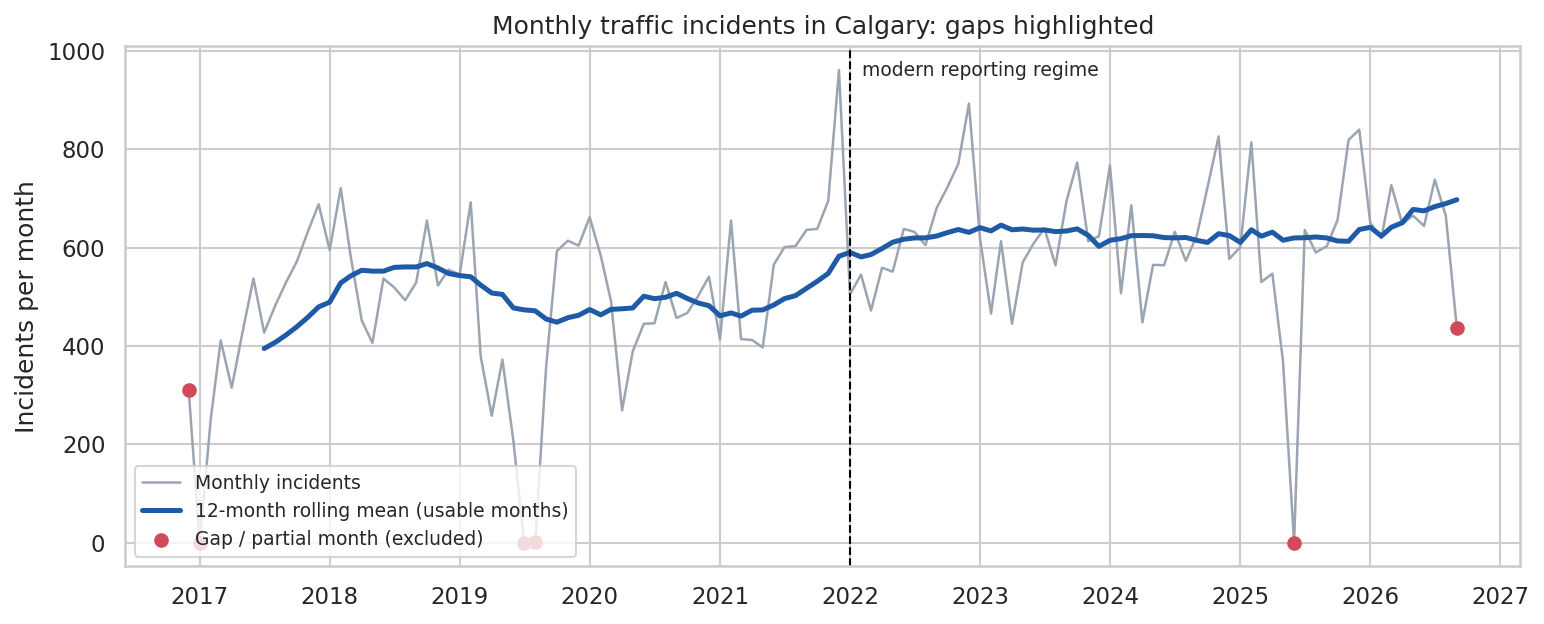

outputs/figures/02_hour_weekday_heatmap.png


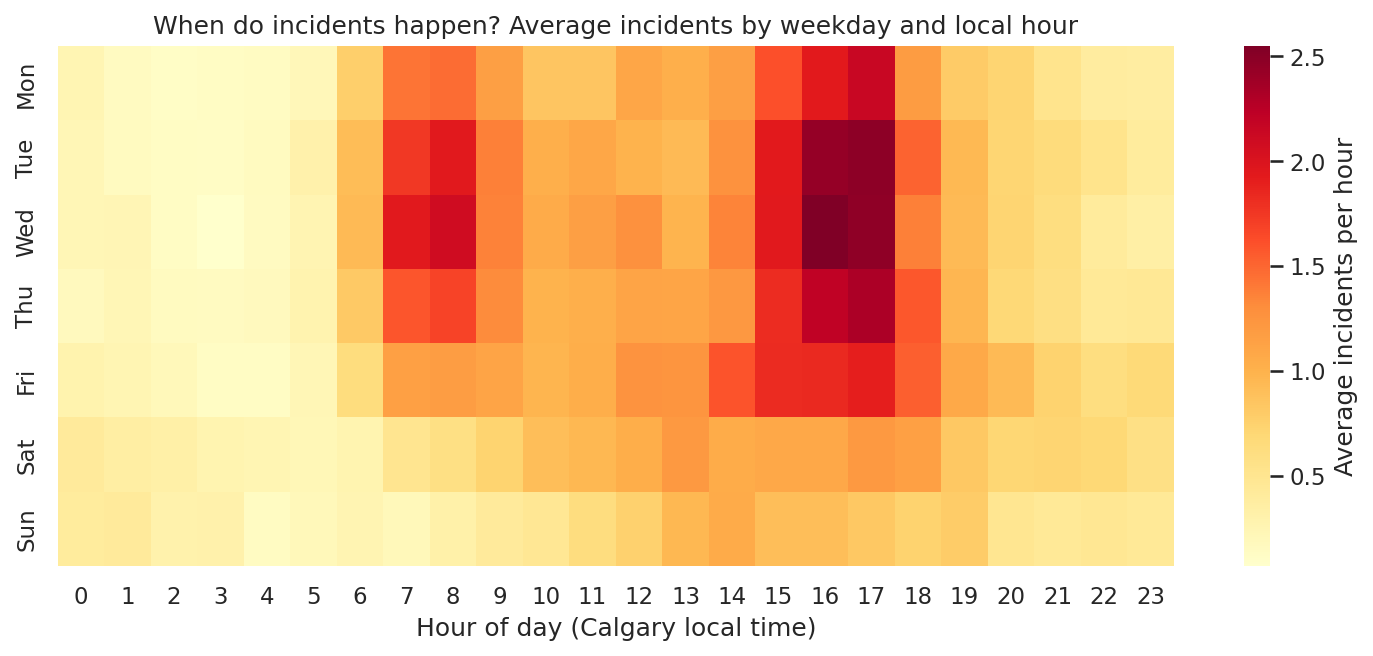

outputs/figures/03_quadrant_profile.png


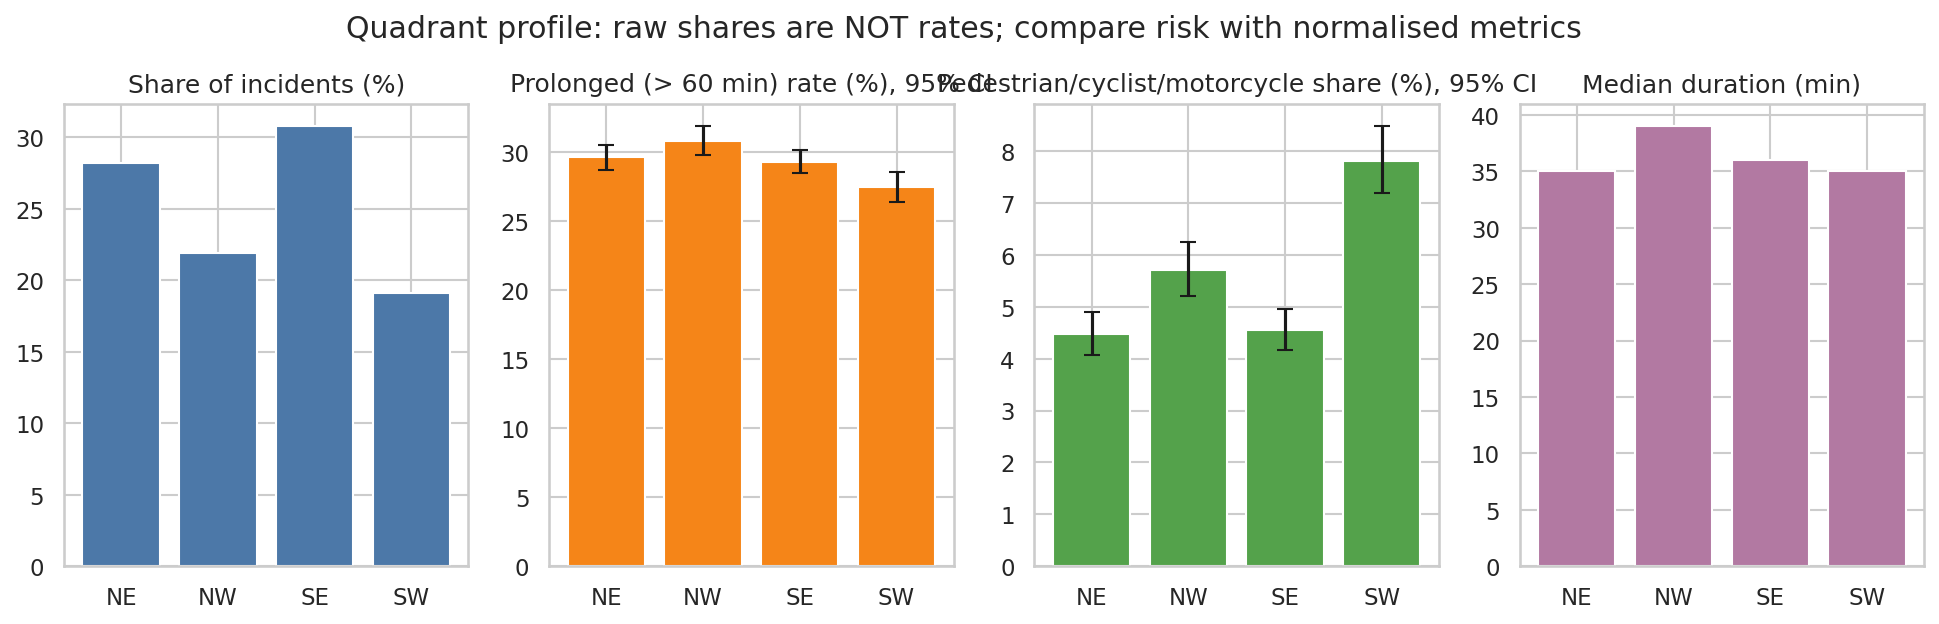

outputs/figures/04_prolonged_rate_heatmap.png


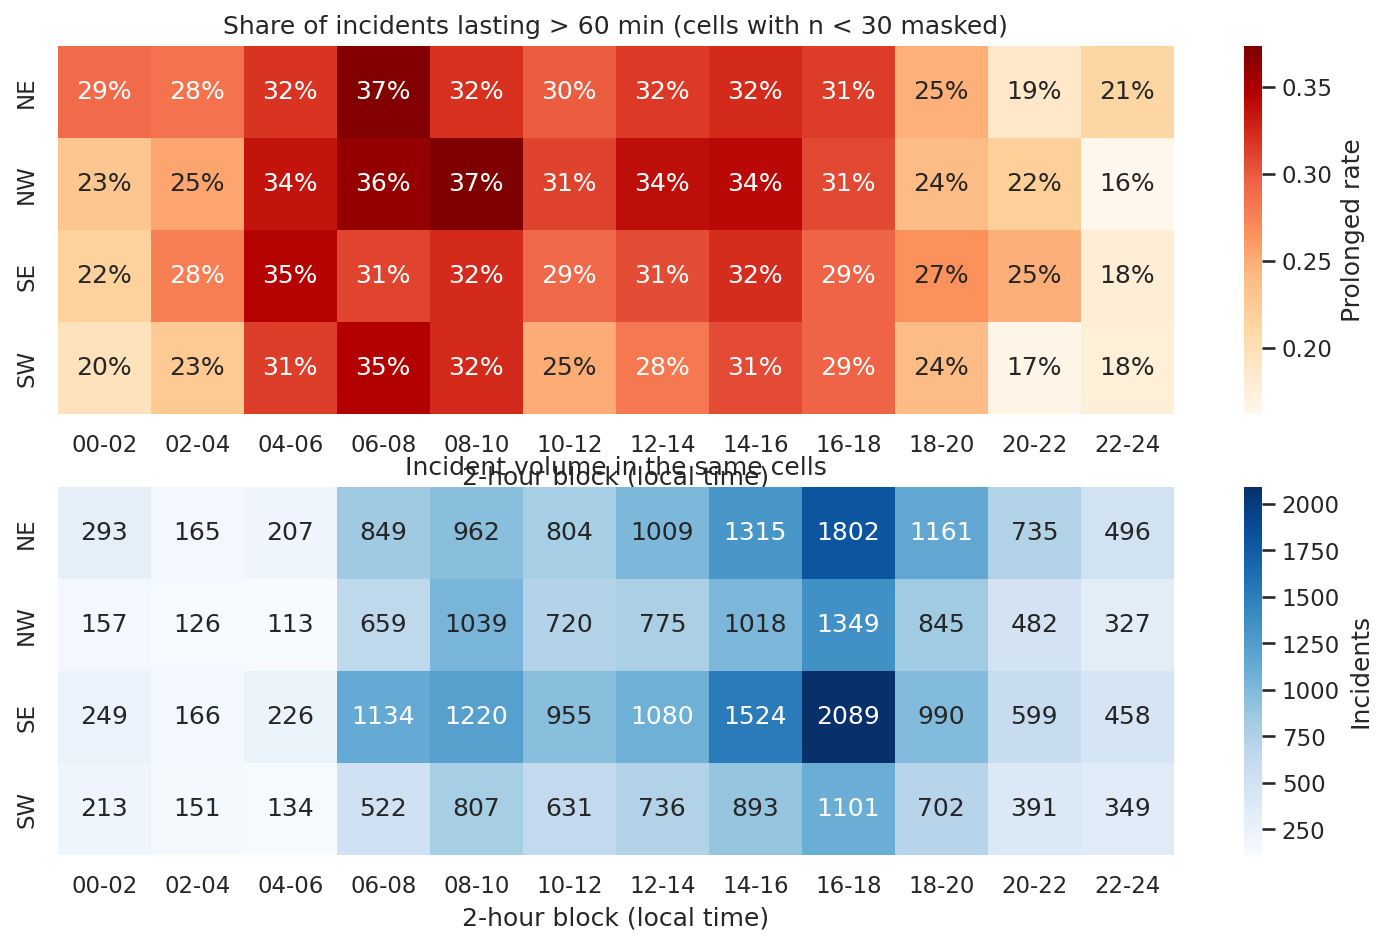

outputs/figures/05_duration_distribution.png


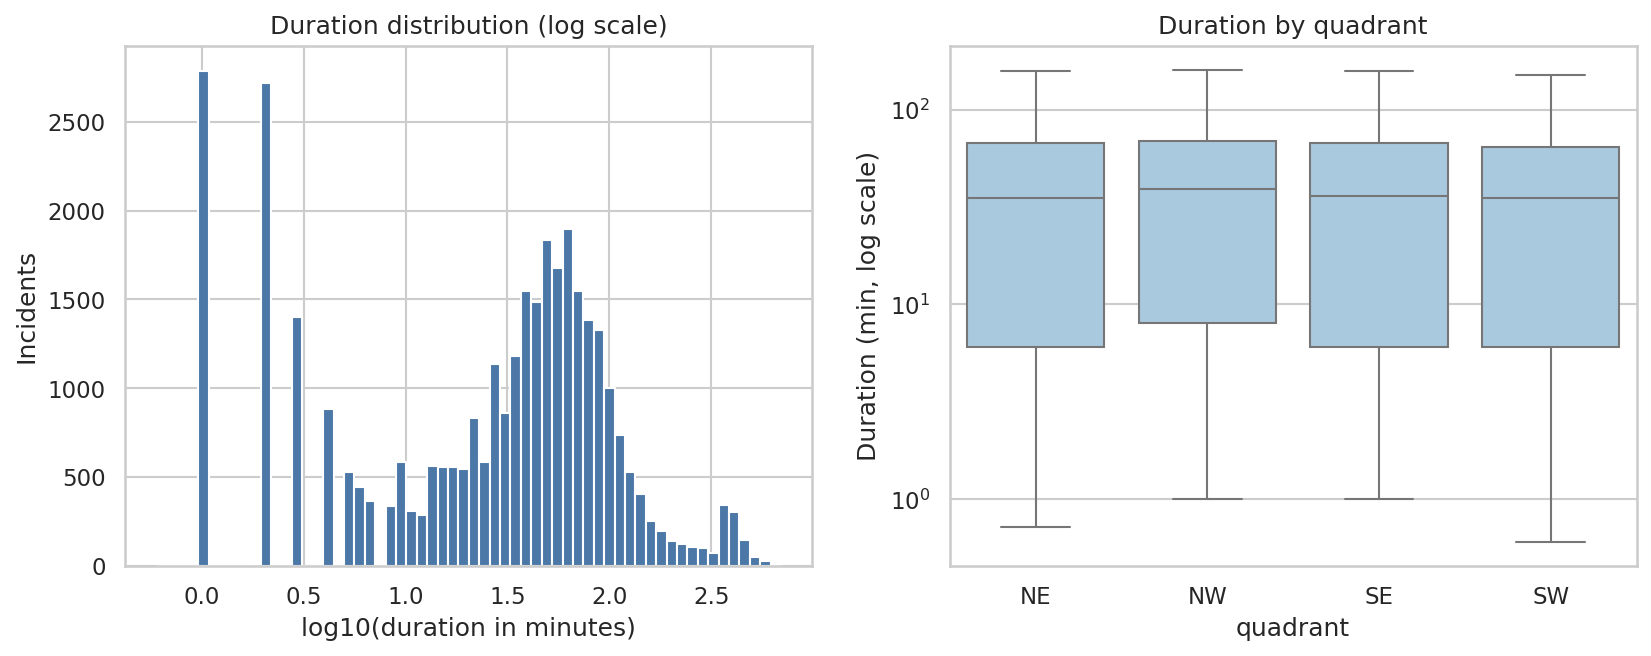

outputs/figures/06_hotspot_density.png


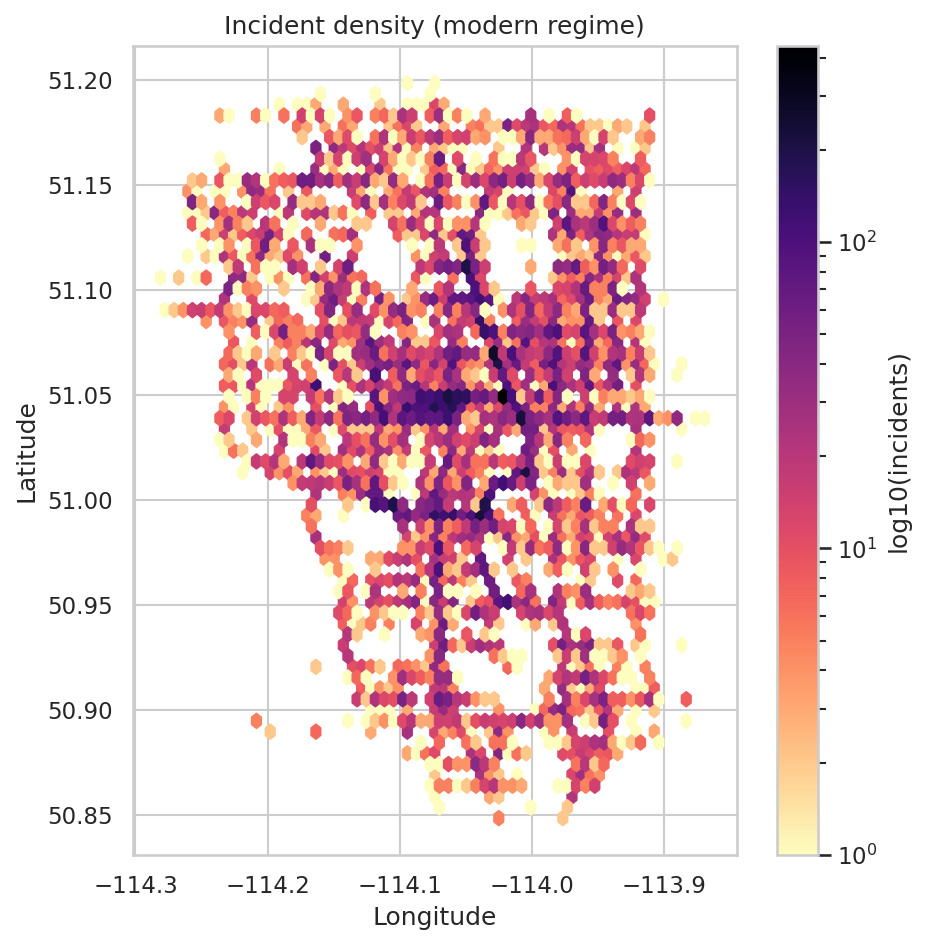

outputs/figures/07_incident_types.png


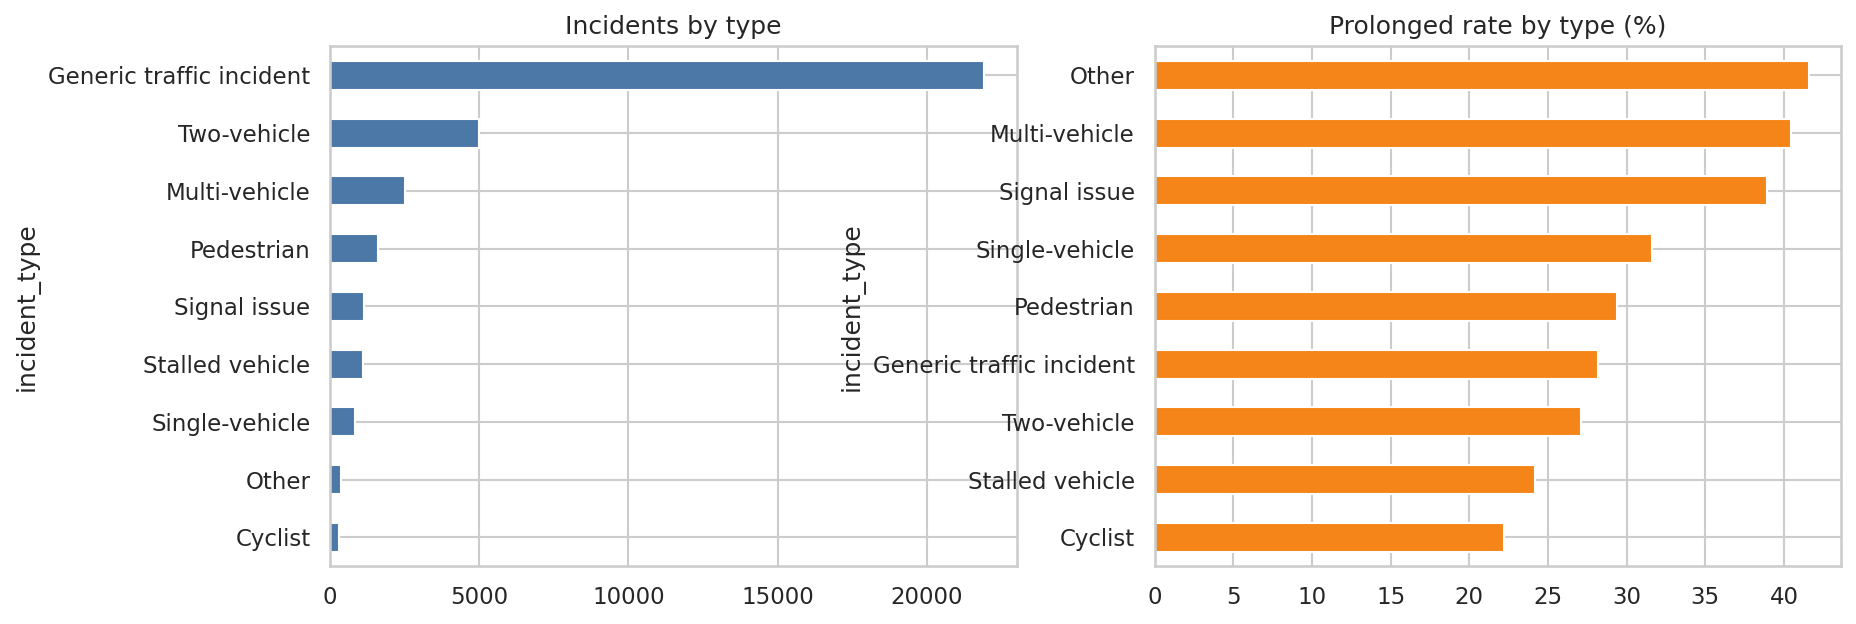

outputs/figures/08_weather_eda.png


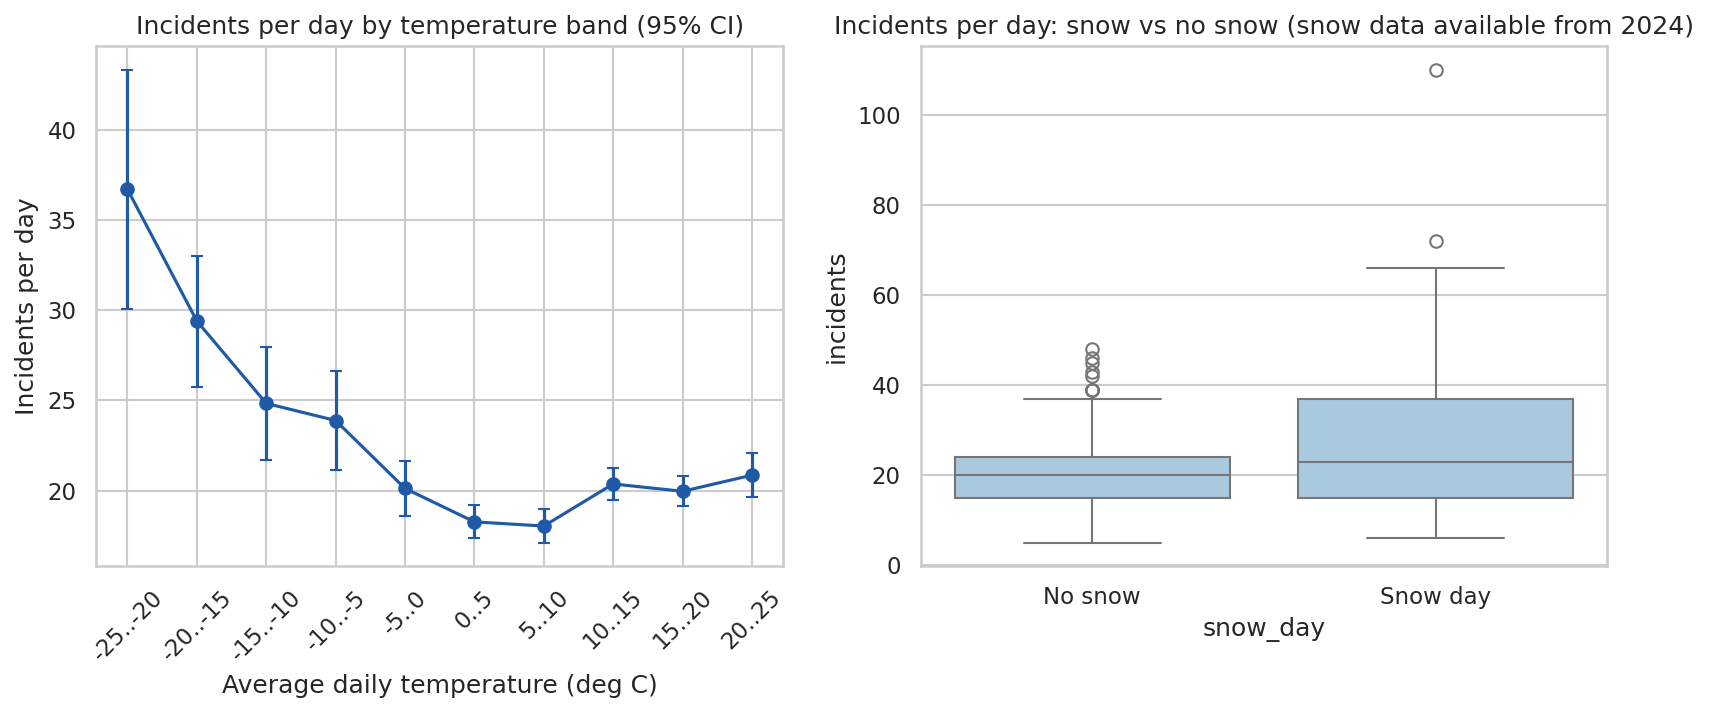

outputs/figures/09_logit_forest_plot.png


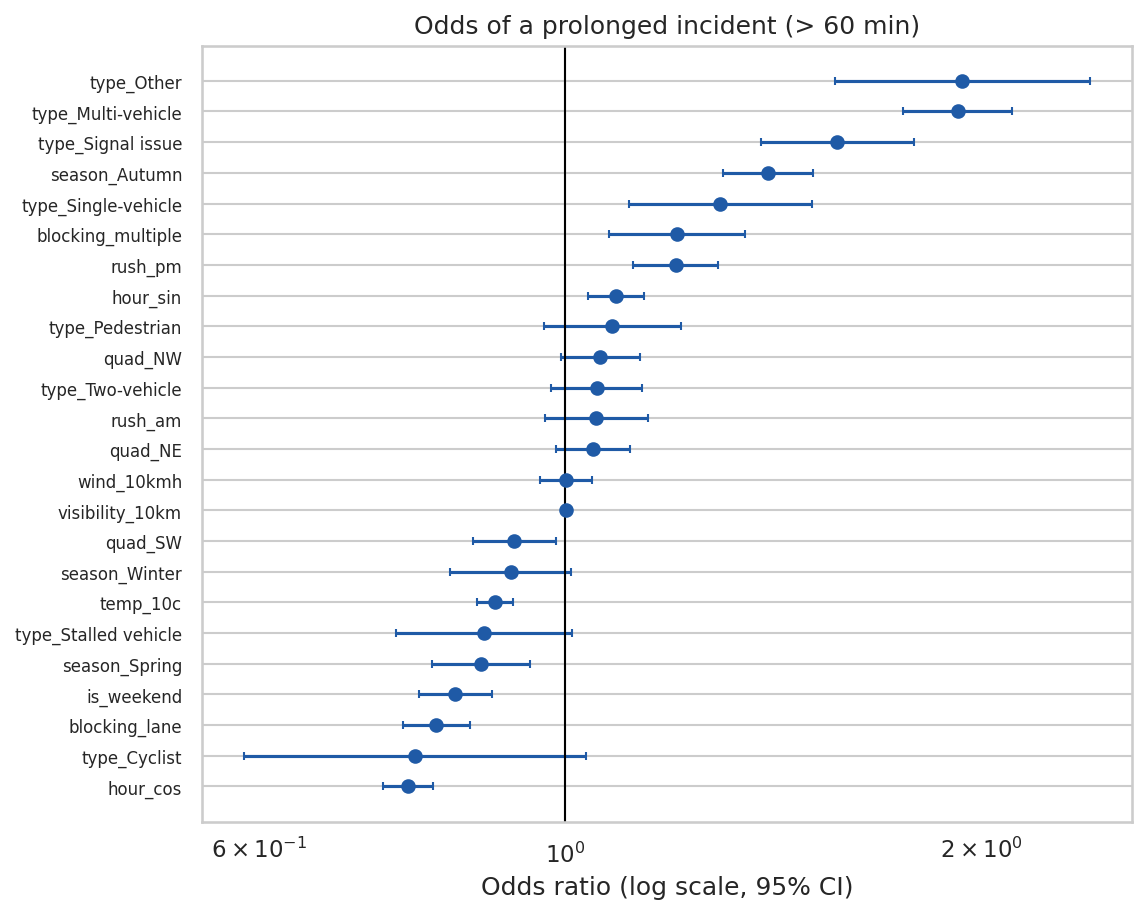

outputs/figures/10_mean_duration_heatmap.png


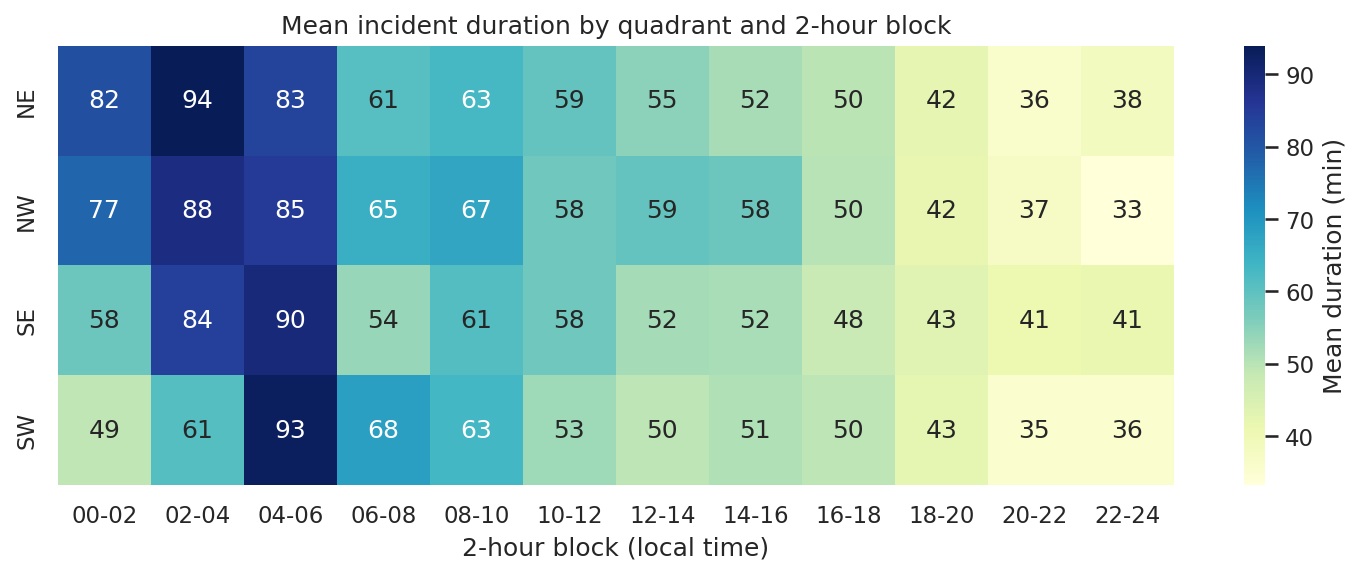

outputs/figures/11_duration_feature_importance.png


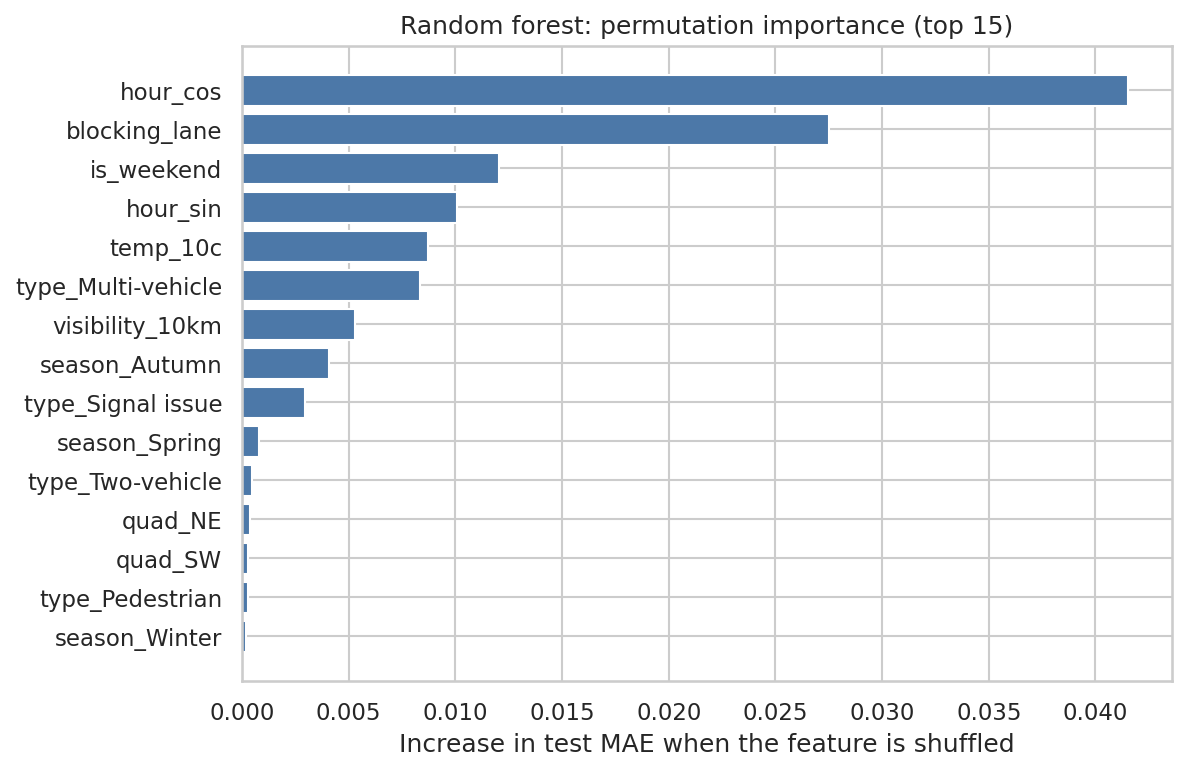

outputs/figures/12_duration_calibration.png


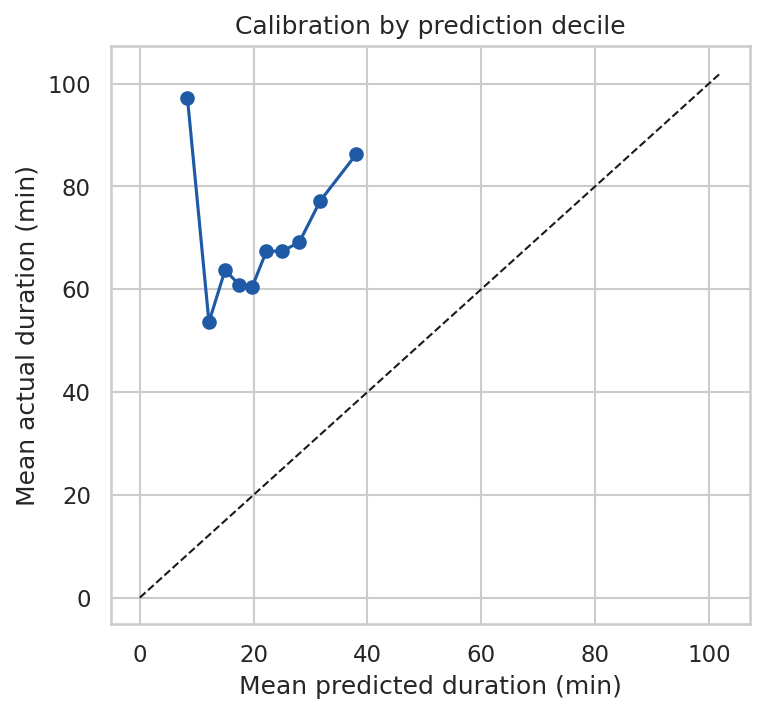

outputs/figures/13_prolonged_classifier_curves.png


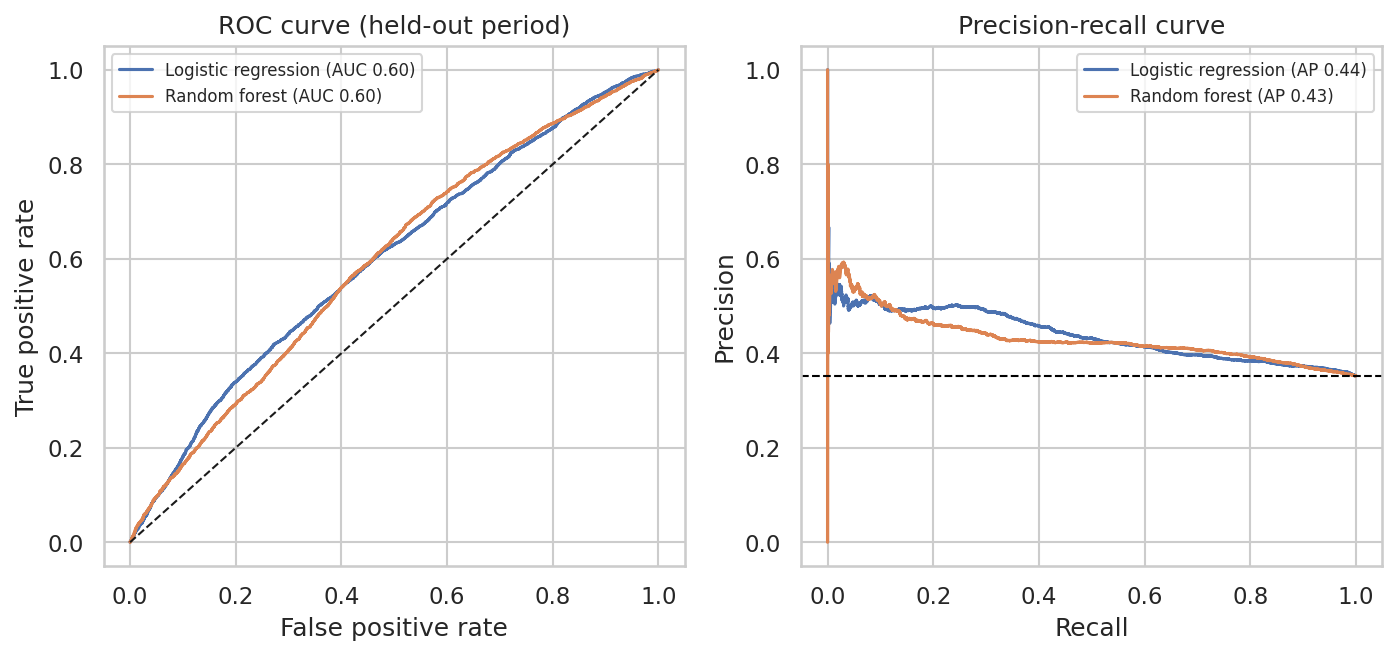

outputs/figures/14_reallocation_heatmaps.png


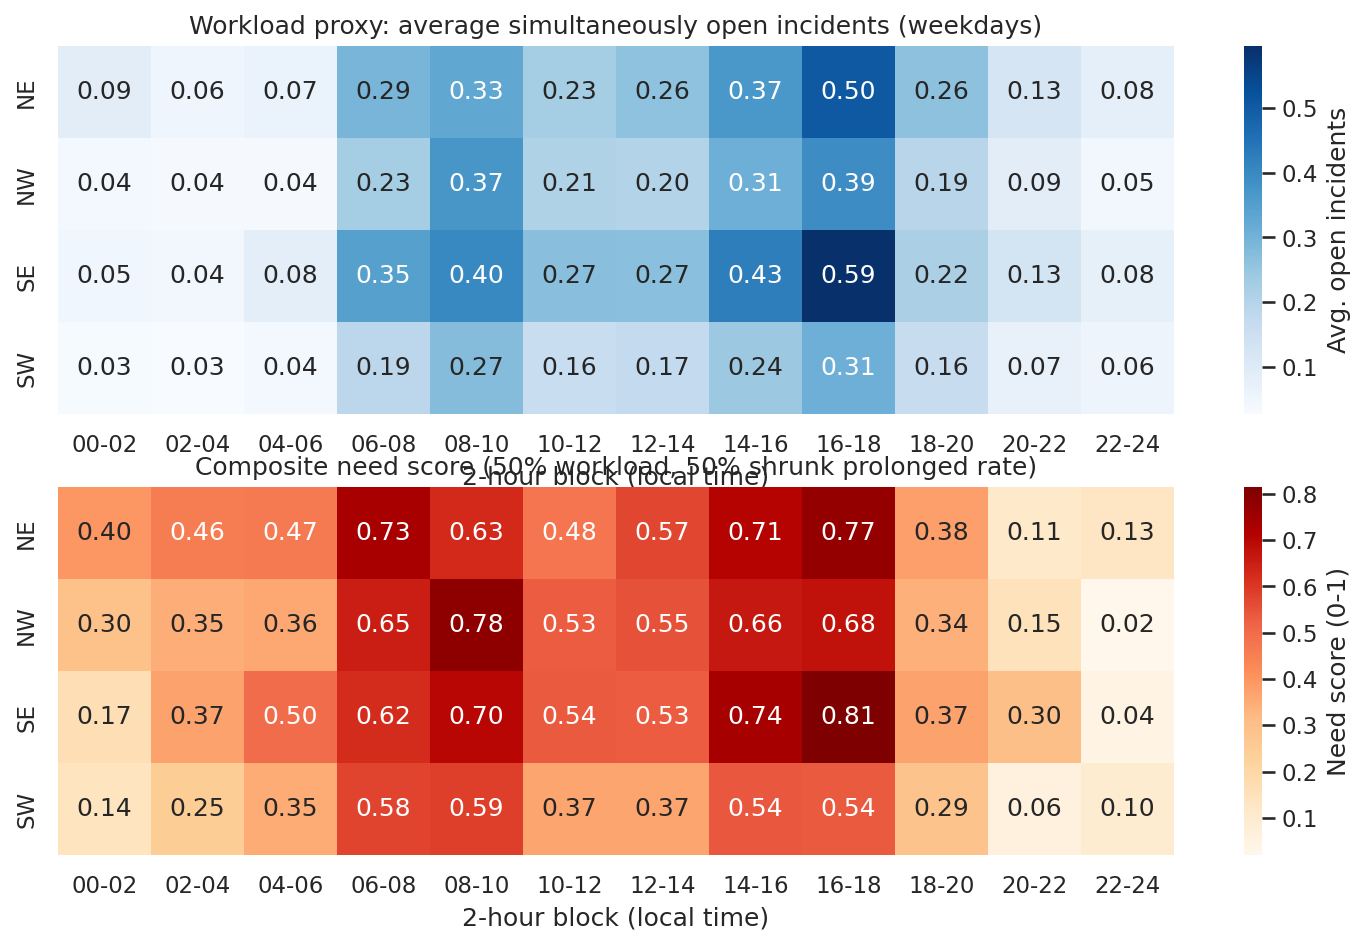

In [4]:
# Show the auto-generated findings and all charts inside the notebook.
from IPython.display import Image, display, Markdown
import glob

display(Markdown(open("outputs/key_findings.md", encoding="utf-8").read()))

for path in sorted(glob.glob("outputs/figures/*.png")):
    print(path)
    display(Image(path))

In [5]:
import pandas as pd
pd.read_csv("outputs/tables/06_quadrant_profile.csv")

,quadrant,incidents,share_of_incidents,prolonged_rate,prolonged_n,prolonged_k,median_duration_min,vru_share,vru_k,prolonged_ci_low,prolonged_ci_high,vru_ci_low,vru_ci_high
0,NE,9798,0.282135,0.296081,9798,2901.0,35.0,0.044703,438.0,0.287122,0.305199,0.040786,0.048976
1,NW,7610,0.219132,0.308279,7610,2346.0,39.0,0.057030,434.0,0.298002,0.318748,0.052040,0.062468
2,SE,10690,0.307821,0.293171,10690,3134.0,36.0,0.045557,487.0,0.284617,0.301874,0.041764,0.049675
3,SW,6630,0.190912,0.274510,6630,1820.0,35.0,0.078130,518.0,0.263900,0.285380,0.071911,0.084837


In [6]:
# Zip the whole outputs folder and download it to your computer.
!zip -r -q outputs.zip outputs
from google.colab import files
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>